# Pet Facial Expression Classification with CNNs
This notebook trains and compares convolutional neural networks on a dataset of pet facial expressions.
It covers dataset download, preprocessing, custom model definitions, training, evaluation, and transfer learning.

In [1]:
import kagglehub
import os
import shutil

# Download latest version
path = kagglehub.dataset_download("anshtanwar/pets-facial-expression-dataset")

print("Path to dataset files:", path)
dataset_dir = "./dataset"
if not os.path.exists(dataset_dir):
    shutil.copytree(path, dataset_dir)

print("Dataset copied to:", dataset_dir)

Using Colab cache for faster access to the 'pets-facial-expression-dataset' dataset.
Path to dataset files: /kaggle/input/pets-facial-expression-dataset
Dataset copied to: ./dataset


## Setup and dependencies
The next cell imports PyTorch and supporting libraries needed for model building, training, visualization, and evaluation.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Reproducibility
This cell sets a random seed for NumPy, Python, and PyTorch to reduce variability across training runs.

In [3]:
import torch
import numpy as np
import random

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)


## Data augmentation and dataset loading
This section defines data transforms for training and evaluation, then loads images from the dataset folders.
Strong augmentation helps the model generalize better across pet facial expressions.

In [4]:
IMG_SIZE = 224

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([

    # Better than Resize + RandomCrop
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    # Blur only sometimes
    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 1.5)
        )
    ], p=0.15),

    transforms.ToTensor(),

    transforms.Normalize(mean=MEAN, std=STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_path = dataset_dir + "/Master Folder/train"
valid_path = dataset_dir + "/Master Folder/valid"
test_path  = dataset_dir + "/Master Folder/test"

train_data = datasets.ImageFolder(train_path, transform=train_transform)
val_data   = datasets.ImageFolder(valid_path, transform=eval_transform)
test_data  = datasets.ImageFolder(test_path,  transform=eval_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_data.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Classes (4): ['Angry', 'Other', 'Sad', 'happy']
Train: 1000 | Val: 36 | Test: 38


## Dataset exploration
Now that the dataset is loaded, this section inspects the class distribution and shows sample augmented images.
Understanding class balance helps identify any dataset skew before training.

/tmp/ipykernel_8659/1797385848.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette="viridis")


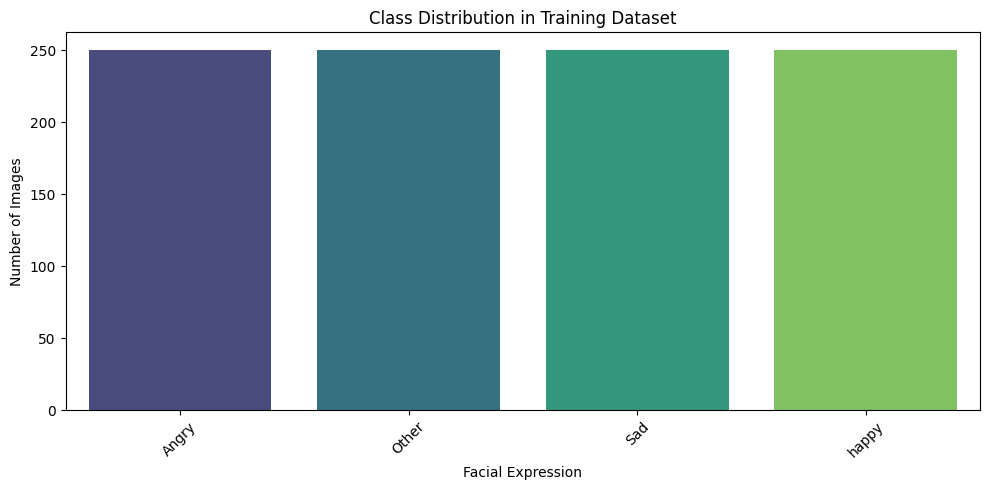

In [5]:
import torchvision
from collections import Counter

train_labels = [label for _, label in train_data.samples]
class_counts = Counter(train_labels)
labels = [CLASS_NAMES[i] for i in class_counts.keys()]
counts = list(class_counts.values())
plt.figure(figsize=(10, 5))
sns.barplot(x=labels, y=counts, palette="viridis")
plt.title('Class Distribution in Training Dataset')
plt.xlabel('Facial Expression')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

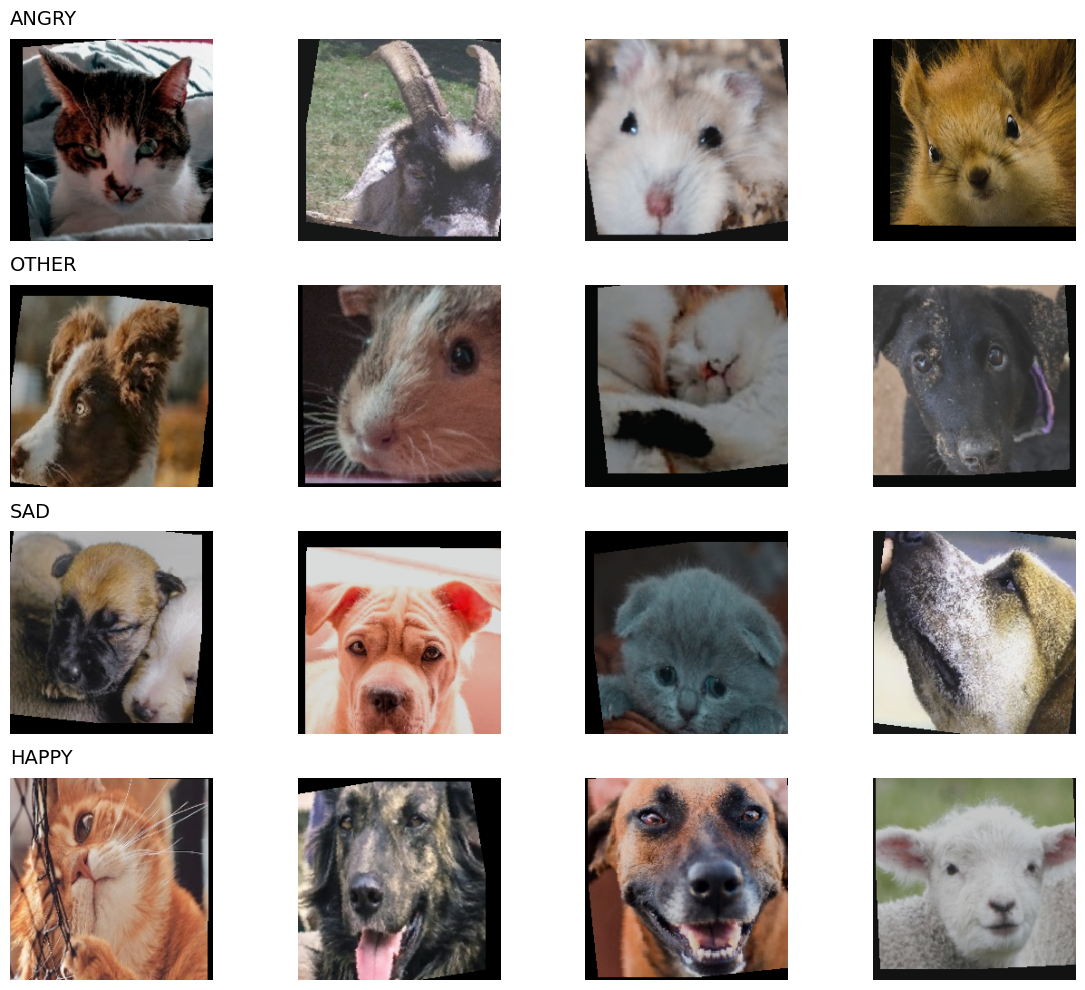

In [6]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Configuration
images_per_class = 4
class_images = {class_name: [] for class_name in CLASS_NAMES}

print("Collecting images from batches...")

# 1. Loop through the loader to collect exactly 4 augmented images per class
for inputs, classes in train_loader:
    for i in range(inputs.size(0)):
        img = inputs[i]
        label_idx = classes[i].item()
        class_name = CLASS_NAMES[label_idx]

        if len(class_images[class_name]) < images_per_class:
            class_images[class_name].append(img)

    # Check if we have 4 images for every single class
    if all(len(imgs) == images_per_class for imgs in class_images.values()):
        break

# 2. Plotting the collected images in a grid (One row per class)
fig, axes = plt.subplots(NUM_CLASSES, images_per_class, figsize=(12, 2.5 * NUM_CLASSES))

for row_idx, class_name in enumerate(CLASS_NAMES):
    for col_idx in range(images_per_class):
        ax = axes[row_idx, col_idx]
        img_tensor = class_images[class_name][col_idx]

        # Un-normalize for human viewing
        img_np = img_tensor.numpy().transpose((1, 2, 0))
        img_np = np.array(STD) * img_np + np.array(MEAN)
        img_np = np.clip(img_np, 0, 1) # Force values between 0 and 1

        ax.imshow(img_np)
        ax.axis('off')

        # Put the class name above the first image in each row
        if col_idx == 0:
            ax.set_title(f"{class_name.upper()}", fontsize=14, loc='left', pad=10)

plt.tight_layout()
plt.show()

In [7]:
def print_distribution(dataset, split_name):
    # Extract all labels from the dataset
    labels = [label for _, label in dataset.samples]
    counts = Counter(labels)

    print(f"\n--- {split_name} Split Distribution ---")
    total = len(labels)
    for class_idx, count in sorted(counts.items()):
        class_name = dataset.classes[class_idx]
        percentage = (count / total) * 100
        print(f"{class_name:<12}: {count} images ({percentage:.1f}%)")

# Run the check
print_distribution(train_data, "Train")
print_distribution(val_data, "Validation")
print_distribution(test_data, "Test")


--- Train Split Distribution ---
Angry       : 250 images (25.0%)
Other       : 250 images (25.0%)
Sad         : 250 images (25.0%)
happy       : 250 images (25.0%)

--- Validation Split Distribution ---
Angry       : 9 images (25.0%)
Other       : 6 images (16.7%)
Sad         : 10 images (27.8%)
happy       : 11 images (30.6%)

--- Test Split Distribution ---
Angry       : 10 images (26.3%)
Other       : 6 images (15.8%)
Sad         : 11 images (28.9%)
happy       : 11 images (28.9%)


## Training utilities
This cell defines reusable training, evaluation, and plotting functions.
The training loop supports early stopping, learning rate scheduling, and auxiliary loss handling for models that return multiple outputs.

In [8]:

def train_model(model, train_loader, val_loader, epochs=25, lr=1e-3, patience=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # Reduce LR if validation loss plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    best_val_loss = float('inf')
    best_weights = None
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs, aux = outputs
                loss = criterion(outputs, labels) + 0.3 * criterion(aux, labels)
            else:
                loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_loss /= len(val_loader.dataset)
        val_acc = correct / total

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc*100:.1f}%")

        # Early stopping — save best weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # Restore best weights
    model.load_state_dict(best_weights)
    return model, history


def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f"\n{'='*50}")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%  (macro)")
    print(f"Recall   : {rec*100:.2f}%  (macro)")
    print(f"F1-Score : {f1*100:.2f}%  (macro)")
    print(f"{'='*50}")
    print("\nPer-class report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   label='Val Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, [v*100 for v in history['val_acc']], label='Val Accuracy', color='green')
    ax2.set_title(f'{title} — Val Accuracy')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Store results for comparison at the end
results_summary = {}

In [9]:
def evaluate(model):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x,y in test_loader:
            x = x.to(device)
            out = model(x)
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())

    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.show()


## Model architectures implemented
This section defines several CNN architectures from scratch. The notebook includes classic and modern networks to compare how different designs perform on the pet facial expression dataset.

### VGG16
VGG16 is a deep, uniform convolutional network that uses repeated 3×3 convolution layers and max-pooling.
It is a strong baseline due to its simple and consistent design, although it is parameter-heavy and slower than later architectures.

In [10]:
import torch
import torch.nn as nn

class VGG16(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        # Convolutional layers
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):

        # Feature extraction
        x = self.features(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Classification
        x = self.classifier(x)

        return x


### ResNet18
ResNet18 introduces residual connections that help gradients flow through deep networks.
These skip connections let the model learn residual functions instead of full mappings, improving training stability and accuracy.

### MobileNetV1
MobileNetV1 uses depthwise separable convolutions to reduce computation while retaining accuracy.
This efficient model is designed for mobile and embedded devices, with a lightweight architecture that is much faster than standard CNNs.

In [11]:
class ResidualBlock(nn.Module):
    """Basic residual block: two 3x3 convs with a skip connection."""

    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # Projection shortcut when spatial or channel dims change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)


class ResNet18(nn.Module):
    """ResNet-18: 4 stages, 2 residual blocks each."""

    def __init__(self, num_classes=4):
        super(ResNet18, self).__init__()
        self.in_channels = 64

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # 4 residual stages
        self.layer1 = self._make_layer(64,  2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = [ResidualBlock(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [12]:
class DepthwiseSeparableConv(nn.Module):
    """Depthwise conv (spatial, per channel) + Pointwise conv (channel mixing)."""

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            # Depthwise: each input channel filtered independently
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1,
                      groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            # Pointwise: 1x1 conv mixes channels
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class MobileNetV1(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        def conv_bn(in_ch, out_ch, stride):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.model = nn.Sequential(
            conv_bn(3, 32, 2),                     # 224 -> 112
            DepthwiseSeparableConv(32,  64,  1),
            DepthwiseSeparableConv(64,  128, 2),   # 112 -> 56
            DepthwiseSeparableConv(128, 128, 1),
            DepthwiseSeparableConv(128, 256, 2),   # 56 -> 28
            DepthwiseSeparableConv(256, 256, 1),
            DepthwiseSeparableConv(256, 512, 2),   # 28 -> 14
            # 5 x same-size blocks
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 1024, 2),  # 14 -> 7
            DepthwiseSeparableConv(1024, 1024, 1),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.model(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


## Inception V3

Inception V3 uses multiple parallel convolution branches at each module to capture multi-scale features. Its architecture balances depth and width by factorizing convolutions and using auxiliary classifiers, making it powerful for complex image classification tasks.

In [13]:
import torch
import torch.nn as nn

# 1. Helper Class: Inception uses this Conv+BatchNorm+ReLU block everywhere
# This acts as the fundamental "Lego brick" for the entire network.
class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv2d, self).__init__()

        # **kwargs allows flexibility to pass any kernel_size, stride, or padding dynamically later.
        # bias=False is used because the subsequent BatchNorm layer cancels out any bias anyway, saving computation.
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)

        # Normalizes the feature maps to prevent internal covariate shift and speed up training.
        # eps=0.001 is a tiny number added to the denominator to prevent "divide by zero" mathematical errors.
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001)

        # Introduces non-linearity. inplace=True modifies the tensor directly rather than allocating new memory, saving massive amounts of RAM.
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # Step 1: Extract features using the convolution
        x = self.conv(x)
        # Step 2: Normalize the extracted feature maps
        x = self.bn(x)
        # Step 3: Apply the activation function and return to the next layer
        return self.relu(x)

In [14]:
# 2. Inception Blocks (A through E)
# InceptionA corresponds to the early phase of the network (handling the 35x35 spatial grid).
class InceptionA(nn.Module):
    def __init__(self, in_channels, pool_features):
        super(InceptionA, self).__init__()

        # BRANCH 1: The direct 1x1 route
        # Captures single-pixel, cross-channel correlations without looking at spatial neighbors.
        self.branch1x1 = BasicConv2d(in_channels, 64, kernel_size=1)

        # BRANCH 2: The 5x5 route
        # First uses a 1x1 bottleneck to reduce channels to 48 (saving computation).
        # Then applies a 5x5 convolution to capture wider spatial patterns. padding=2 keeps the grid size identical.
        self.branch5x5_1 = BasicConv2d(in_channels, 48, kernel_size=1)
        self.branch5x5_2 = BasicConv2d(48, 64, kernel_size=5, padding=2)

        # BRANCH 3: The "Double 3x3" route (Factorization)
        # Uses a 1x1 bottleneck to reduce channels to 64.
        # Then stacks two 3x3 convolutions. This achieves the same "field of vision" as a 5x5
        # but uses fewer parameters and adds more non-linearity (more ReLUs). padding=1 keeps the grid size identical.
        self.branch3x3dbl_1 = BasicConv2d(in_channels, 64, kernel_size=1)
        self.branch3x3dbl_2 = BasicConv2d(64, 96, kernel_size=3, padding=1)
        self.branch3x3dbl_3 = BasicConv2d(96, 96, kernel_size=3, padding=1)

        # BRANCH 4: The Pooling route
        # Will pool first in the forward pass, then use this 1x1 convolution to reduce the
        # channel depth so it doesn't overwhelm the other branches when concatenated.
        self.branch_pool = BasicConv2d(in_channels, pool_features, kernel_size=1)

    def forward(self, x):
        # Run the exact same input 'x' through all four branches simultaneously

        # Branch 1 execution
        branch1x1 = self.branch1x1(x)

        # Branch 2 execution (Bottleneck -> 5x5)
        branch5x5 = self.branch5x5_1(x)
        branch5x5 = self.branch5x5_2(branch5x5)

        # Branch 3 execution (Bottleneck -> 3x3 -> 3x3)
        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = self.branch3x3dbl_3(branch3x3dbl)

        # Branch 4 execution (Average Pool -> Bottleneck)
        # stride=1 and padding=1 ensure the spatial grid does not shrink here
        branch_pool = torch.nn.functional.avg_pool2d(x, kernel_size=3, stride=1, padding=1)
        branch_pool = self.branch_pool(branch_pool)

        # Merge all four branches together along dimension 1 (the channel dimension)
        # The output has the same height/width, but a massively expanded and specialized channel depth.
        return torch.cat([branch1x1, branch5x5, branch3x3dbl, branch_pool], 1)

In [15]:
class InceptionB(nn.Module): # Reduction Block A
    def __init__(self, in_channels):
        super(InceptionB, self).__init__()

        # BRANCH 1: Single 3x3 Reduction
        # Applies a 3x3 convolution with stride=2. This extracts meaningful spatial
        # features while simultaneously cutting the height and width of the grid in half.
        self.branch3x3 = BasicConv2d(in_channels, 384, kernel_size=3, stride=2)

        # BRANCH 2: Double 3x3 Reduction
        # Starts with a 1x1 bottleneck to compress channels down to 64.
        self.branch3x3dbl_1 = BasicConv2d(in_channels, 64, kernel_size=1)
        # Applies a standard 3x3 convolution (padding=1 keeps grid size the same here).
        self.branch3x3dbl_2 = BasicConv2d(64, 96, kernel_size=3, padding=1)
        # Applies a second 3x3 convolution, this time with stride=2 to cut the grid in half.
        # This branch extracts highly complex features before stepping down the resolution.
        self.branch3x3dbl_3 = BasicConv2d(96, 96, kernel_size=3, stride=2)

    def forward(self, x):
        # Branch 1 execution
        branch3x3 = self.branch3x3(x)

        # Branch 2 execution (Bottleneck -> 3x3 -> 3x3 strided)
        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = self.branch3x3dbl_3(branch3x3dbl)

        # Branch 3 execution (Direct Pooling)
        # Standard Max Pooling with stride=2 to keep the most prominent features.
        # (Notice there is no 1x1 convolution after this, so it retains the original 'in_channels' depth).
        branch_pool = torch.nn.functional.max_pool2d(x, kernel_size=3, stride=2)

        # Merge all three branches.
        # Because every branch applied an operation with stride=2, their spatial dimensions
        # (height and width) match perfectly, allowing them to be stacked on the channel dimension.
        return torch.cat([branch3x3, branch3x3dbl, branch_pool], 1)

In [16]:
class InceptionC(nn.Module):
    def __init__(self, in_channels, channels_7x7):
        super(InceptionC, self).__init__()

        # BRANCH 1: The direct 1x1 route
        self.branch1x1 = BasicConv2d(in_channels, 192, kernel_size=1)

        c7 = channels_7x7

        # BRANCH 2: Asymmetric 7x7 Factorization
        # Replaces a single 7x7 convolution (which requires 49 parameters per channel).
        # Starts with a 1x1 bottleneck to reduce depth.
        self.branch7x7_1 = BasicConv2d(in_channels, c7, kernel_size=1)
        # Applies a horizontal 1x7 filter. padding=(0, 3) pads exactly 3 pixels on the left/right
        # to ensure the grid width doesn't shrink.
        self.branch7x7_2 = BasicConv2d(c7, c7, kernel_size=(1, 7), padding=(0, 3))
        # Applies a vertical 7x1 filter. padding=(3, 0) pads exactly 3 pixels on top/bottom.
        # Combined, these two layers achieve a 7x7 "field of vision" for just 14 parameters (7+7)
        # instead of 49, saving massive computation time while adding an extra ReLU non-linearity.
        self.branch7x7_3 = BasicConv2d(c7, 192, kernel_size=(7, 1), padding=(3, 0))

        # BRANCH 3: The Deep Asymmetric Stack (Double 7x7 Factorization)
        # Acts like a massive, highly non-linear feature extractor (replacing something like an 11x11 filter).
        self.branch7x7dbl_1 = BasicConv2d(in_channels, c7, kernel_size=1)
        # First alternating pair of vertical and horizontal filters
        self.branch7x7dbl_2 = BasicConv2d(c7, c7, kernel_size=(7, 1), padding=(3, 0))
        self.branch7x7dbl_3 = BasicConv2d(c7, c7, kernel_size=(1, 7), padding=(0, 3))
        # Second alternating pair of vertical and horizontal filters
        self.branch7x7dbl_4 = BasicConv2d(c7, c7, kernel_size=(7, 1), padding=(3, 0))
        self.branch7x7dbl_5 = BasicConv2d(c7, 192, kernel_size=(1, 7), padding=(0, 3))

        # BRANCH 4: The Pooling route
        # Standard 1x1 bottleneck attached to the pooling output to reduce channel depth.
        self.branch_pool = BasicConv2d(in_channels, 192, kernel_size=1)

    def forward(self, x):
        # Branch 1 execution
        branch1x1 = self.branch1x1(x)

        # Branch 2 execution (Bottleneck -> Horizontal -> Vertical)
        branch7x7 = self.branch7x7_1(x)
        branch7x7 = self.branch7x7_2(branch7x7)
        branch7x7 = self.branch7x7_3(branch7x7)

        # Branch 3 execution (Bottleneck -> Vertical -> Horizontal -> Vertical -> Horizontal)
        branch7x7dbl = self.branch7x7dbl_1(x)
        branch7x7dbl = self.branch7x7dbl_2(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_3(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_4(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_5(branch7x7dbl)

        # Branch 4 execution (Average Pool -> Bottleneck)
        # stride=1 and padding=1 ensure the spatial grid remains identical to the other branches.
        branch_pool = torch.nn.functional.avg_pool2d(x, kernel_size=3, stride=1, padding=1)
        branch_pool = self.branch_pool(branch_pool)

        # Merge all four branches together.
        # Since all spatial grids are maintained at 17x17, they stack perfectly on the channel dimension.
        return torch.cat([branch1x1, branch7x7, branch7x7dbl, branch_pool], 1)

In [17]:
class InceptionD(nn.Module): # Reduction Block B
    def __init__(self, in_channels):
        super(InceptionD, self).__init__()

        # BRANCH 1: The Direct Reduction Route
        # Uses a 1x1 bottleneck to reduce incoming channels to 192.
        self.branch3x3_1 = BasicConv2d(in_channels, 192, kernel_size=1)
        # Applies a standard 3x3 convolution with stride=2.
        # This cuts the 17x17 spatial grid exactly in half to 8x8 while extracting basic spatial features.
        self.branch3x3_2 = BasicConv2d(192, 320, kernel_size=3, stride=2)

        # BRANCH 2: The Deep Analytical Reduction Route
        # Starts with a 1x1 bottleneck.
        self.branch7x7x3_1 = BasicConv2d(in_channels, 192, kernel_size=1)
        # Applies the Asymmetric Factorization trick (1x7 then 7x1).
        # padding=(0, 3) and (3, 0) keep the grid perfectly at 17x17 during these steps.
        # This allows the network to extract highly complex, cross-spatial features BEFORE stepping down the resolution.
        self.branch7x7x3_2 = BasicConv2d(192, 192, kernel_size=(1, 7), padding=(0, 3))
        self.branch7x7x3_3 = BasicConv2d(192, 192, kernel_size=(7, 1), padding=(3, 0))
        # Finally, applies a 3x3 convolution with stride=2 to shrink the grid down to 8x8.
        self.branch7x7x3_4 = BasicConv2d(192, 192, kernel_size=3, stride=2)

    def forward(self, x):
        # Branch 1 execution (Bottleneck -> 3x3 strided)
        branch3x3 = self.branch3x3_1(x)
        branch3x3 = self.branch3x3_2(branch3x3)

        # Branch 2 execution (Bottleneck -> Horizontal -> Vertical -> 3x3 strided)
        branch7x7x3 = self.branch7x7x3_1(x)
        branch7x7x3 = self.branch7x7x3_2(branch7x7x3)
        branch7x7x3 = self.branch7x7x3_3(branch7x7x3)
        branch7x7x3 = self.branch7x7x3_4(branch7x7x3)

        # Branch 3 execution (The Anchor)
        # Standard Max Pooling with stride=2.
        # Ensures the absolute strongest, most dominant activations from the 17x17 grid
        # survive the reduction to the 8x8 grid unmodified.
        branch_pool = torch.nn.functional.max_pool2d(x, kernel_size=3, stride=2)

        # Merge all three branches.
        # Because every branch ends with an operation using stride=2, they all output
        # perfectly aligned 8x8 grids. Stacking them on the channel dimension creates a deep, abstract tensor.
        return torch.cat([branch3x3, branch7x7x3, branch_pool], 1)

In [18]:
class InceptionE(nn.Module):
    def __init__(self, in_channels):
        super(InceptionE, self).__init__()

        # BRANCH 1: The Direct Route
        self.branch1x1 = BasicConv2d(in_channels, 320, kernel_size=1)

        # BRANCH 2: The "Wide" Split Route
        # Starts with a 1x1 bottleneck to reduce incoming channels to 384.
        self.branch3x3_1 = BasicConv2d(in_channels, 384, kernel_size=1)
        # Instead of stacking these sequentially (like InceptionC), these will run in parallel.
        # padding=(0, 1) and (1, 0) keep the spatial grid perfectly at 8x8.
        self.branch3x3_2a = BasicConv2d(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.branch3x3_2b = BasicConv2d(384, 384, kernel_size=(3, 1), padding=(1, 0))

        # BRANCH 3: The Deep-to-Wide Split Route
        # Starts with a 1x1 bottleneck.
        self.branch3x3dbl_1 = BasicConv2d(in_channels, 448, kernel_size=1)
        # Processes the features spatially first with a standard 3x3.
        self.branch3x3dbl_2 = BasicConv2d(448, 384, kernel_size=3, padding=1)
        # Then, just like Branch 2, prepares a horizontal and vertical filter to run in parallel.
        # This branch handles the most complex, tangled features by giving them an extra layer of processing.
        self.branch3x3dbl_3a = BasicConv2d(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.branch3x3dbl_3b = BasicConv2d(384, 384, kernel_size=(3, 1), padding=(1, 0))

        # BRANCH 4: The Pooling Route
        # Preserves a baseline of spatial averages, squashing depth to 192.
        self.branch_pool = BasicConv2d(in_channels, 192, kernel_size=1)

    def forward(self, x):
        # Branch 1 execution
        branch1x1 = self.branch1x1(x)

        # Branch 2 execution (Bottleneck -> Parallel Split -> Internal Concat)
        branch3x3 = self.branch3x3_1(x)
        # THE SHIFT: Notice the torch.cat here! The data is passed to the 1x3 and 3x1 AT THE SAME TIME.
        # This exponentially expands the "filter bank space," creating highly rich representations.
        branch3x3 = torch.cat([self.branch3x3_2a(branch3x3), self.branch3x3_2b(branch3x3)], 1)

        # Branch 3 execution (Bottleneck -> Spatial 3x3 -> Parallel Split -> Internal Concat)
        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        # Again, wide parallel factorization at the end of the branch.
        branch3x3dbl = torch.cat([self.branch3x3dbl_3a(branch3x3dbl), self.branch3x3dbl_3b(branch3x3dbl)], 1)

        # Branch 4 execution (Average Pool -> Bottleneck)
        branch_pool = torch.nn.functional.avg_pool2d(x, kernel_size=3, stride=1, padding=1)
        branch_pool = self.branch_pool(branch_pool)

        # Final Merge
        # Stacks all the highly abstract, deep, and wide features together.
        # In the full model, this produces the final massive 8x8x2048 tensor ready for global pooling.
        return torch.cat([branch1x1, branch3x3, branch3x3dbl, branch_pool], 1)

In [19]:
# 3. Auxiliary Classifier
class InceptionAux(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(InceptionAux, self).__init__()

        # 1x1 Bottleneck to rapidly reduce channel depth from 768 to 128
        self.conv0 = BasicConv2d(in_channels, 128, kernel_size=1)

        # 5x5 Convolution to process the remaining spatial grid and expand channels back to 768
        self.conv1 = BasicConv2d(128, 768, kernel_size=5)

        # Custom Variance Initialization:
        # Forces the initial random weights to be very small. Because this branch injects gradients
        # directly into the middle of the network, large random weights would cause chaotic gradient spikes.
        self.conv1.stddev = 0.01

        # Final fully connected layer to map the 768 features to the dataset's categories
        self.fc = nn.Linear(768, num_classes)
        self.fc.stddev = 0.001

    def forward(self, x):
        # Input arrives from Mixed_6e.
        # Current shape: 17 x 17 spatial grid with 768 channels.

        # Aggressive Pooling: 5x5 window skipping 3 pixels at a time.
        # Math: (17 - 5) / 3 + 1 = 5. The spatial grid rapidly shrinks to 5x5.
        x = torch.nn.functional.avg_pool2d(x, kernel_size=5, stride=3)

        # 5 x 5 x 768
        # Bottleneck reduces depth.
        x = self.conv0(x)

        # 5 x 5 x 128
        # Because the grid is exactly 5x5 and there is no padding, applying a 5x5 filter
        # consumes the ENTIRE spatial area in one step. The output grid collapses to 1x1.
        x = self.conv1(x)

        # 1 x 1 x 768
        # Strips away the 2D spatial dimensions (the 1x1), turning the cube into a flat 1D array.
        x = torch.flatten(x, 1)

        # Passes the flat 768 vector into the linear layer for the auxiliary class prediction.
        x = self.fc(x)
        return x

In [20]:
# 4. The Main Inception V3 Architecture
class InceptionV3_FromScratch(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, aux_logits=True):
        super(InceptionV3_FromScratch, self).__init__()
        self.aux_logits = aux_logits

        # ==========================================
        # STEM: Rapid Downsampling
        # Purpose: Shrink initial massive image safely
        # ==========================================
        # Stem 299*299 -> 35*35
        self.Conv2d_1a_3x3 = BasicConv2d(3, 32, kernel_size=3, stride=2)    # 299 -> 149
        self.Conv2d_2a_3x3 = BasicConv2d(32, 32, kernel_size=3)             # 149 -> 147
        self.Conv2d_2b_3x3 = BasicConv2d(32, 64, kernel_size=3, padding=1)  # 147 -> 147
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2)               # 147 -> 73
        self.Conv2d_3b_1x1 = BasicConv2d(64, 80, kernel_size=1)             # 73 -> 73
        self.Conv2d_4a_3x3 = BasicConv2d(80, 192, kernel_size=3)            # 73 -> 71
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2)               # 71 -> 35

        # ==========================================
        # INCEPTION BLOCKS: Multi-scale processing
        # ==========================================
        # Inception Blocks
        # 35*35 Grid Phase (Basic 5x5 Factorization)
        self.Mixed_5b = InceptionA(192, pool_features=32)
        self.Mixed_5c = InceptionA(256, pool_features=64)
        self.Mixed_5d = InceptionA(288, pool_features=64)

        # 17*17 Grid Phase (Asymmetric 1x7 / 7x1 Factorization)
        self.Mixed_6a = InceptionB(288)                                     # Grid Reduction A (35 -> 17)
        self.Mixed_6b = InceptionC(768, channels_7x7=128)
        self.Mixed_6c = InceptionC(768, channels_7x7=160)
        self.Mixed_6d = InceptionC(768, channels_7x7=160)
        self.Mixed_6e = InceptionC(768, channels_7x7=192)

        # Auxiliary Classifier (Attached to Mixed_6e)
        # Purpose: Injects gradients to middle layers to prevent vanishing gradients
        if aux_logits:
            self.AuxLogits = InceptionAux(768, num_classes)

        # 8*8 Grid Phase (Wide Parallel Factorization)
        self.Mixed_7a = InceptionD(768)                                     # Grid Reduction B (17 -> 8)
        self.Mixed_7b = InceptionE(1280)
        self.Mixed_7c = InceptionE(2048)                                    # Final feature tensor: 8x8x2048

        # ==========================================
        # FINAL CLASSIFIER
        # ==========================================
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))                         # Squashes 8x8 spatial grid into 1x1 globally
        self.dropout = nn.Dropout()                                         # Randomly drops connections to prevent overfitting
        self.fc = nn.Linear(2048, num_classes)                              # Maps the 2048 features to final categories

    def forward(self, x):
        # Stem (Funneling the massive image down)
        x = self.Conv2d_1a_3x3(x)
        x = self.Conv2d_2a_3x3(x)
        x = self.Conv2d_2b_3x3(x)
        x = self.maxpool1(x)
        x = self.Conv2d_3b_1x1(x)
        x = self.Conv2d_4a_3x3(x)
        x = self.maxpool2(x)

        # 35 x 35 Phase (Extracting simple geometric shapes)
        x = self.Mixed_5b(x)
        x = self.Mixed_5c(x)
        x = self.Mixed_5d(x)

        # 17 x 17 Phase (Extracting complex spatial features asymmetrically)
        x = self.Mixed_6a(x)    # Halves the grid
        x = self.Mixed_6b(x)
        x = self.Mixed_6c(x)
        x = self.Mixed_6d(x)
        x = self.Mixed_6e(x)

        # Aux Classifier Branch (Only runs during training!)
        aux = None
        if self.training and self.aux_logits:
            aux = self.AuxLogits(x)

        # 8 x 8 Phase (Extracting final, highly abstract deep features)
        x = self.Mixed_7a(x)    # Halves the grid again
        x = self.Mixed_7b(x)
        x = self.Mixed_7c(x)

        # Final Classifier (Turning feature maps into class probabilities)
        x = self.avgpool(x)     # Global Average Pooling (8x8 -> 1x1)
        x = self.dropout(x)
        x = torch.flatten(x, 1) # Flattens to a 1D vector of 2048 elements
        x = self.fc(x)

        # If training, return both final prediction and aux prediction for loss calculation
        if self.training and self.aux_logits:
            return x, aux

        # If in production/eval mode, just return the final prediction
        return x

## DenseNet121

DenseNet121 connects each layer to every other layer in a feed-forward fashion, encouraging feature reuse and reducing the number of parameters. This dense connectivity improves gradient flow and helps the model learn compact, efficient representations for classification.

In [21]:
class DenseLayer(nn.Module):
    """Single dense layer: BN→ReLU→Conv1×1 (bottleneck) → BN→ReLU→Conv3×3."""
    def __init__(self, in_ch, growth_rate):
        super().__init__()
        # The bottleneck size is strictly defined as 4x the growth rate (k)
        hidden = 4 * growth_rate

        # H_l: The composite function defined by the DenseNet architecture
        self.block = nn.Sequential(
            # Step 1: Pre-activation (Batch Norm + ReLU)
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),

            # Step 2: 1x1 Convolution to bottleneck the input down to 'hidden' channels
            # bias is False because the preceding BatchNorm makes it redundant
            nn.Conv2d(in_ch, hidden, 1, bias=False),

            # Step 3: Second Pre-activation for the spatial convolution
            nn.BatchNorm2d(hidden), nn.ReLU(inplace=True),

            # Step 4: 3x3 Spatial Convolution producing exactly 'growth_rate' (k) new feature maps
            # padding=1 ensures the spatial dimensions (H, W) remain unchanged for concatenation
            nn.Conv2d(hidden, growth_rate, 3, padding=1, bias=False),
        )

    def forward(self, x):
        # Concatenate the accumulated previous features (x) with the k new features (self.block(x))
        # dim=1 corresponds to the channel dimension in PyTorch tensors (N, C, H, W)
        return torch.cat([x, self.block(x)], dim=1)   # dense connection

In [22]:
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_ch, growth_rate):
        super().__init__()
        layers = []

        # Build the block by stacking 'num_layers' DenseLayers
        for i in range(num_layers):
            # The input channels grow linearly. Layer 'i' receives the original 'in_ch'
            # PLUS the 'growth_rate' (k) accumulated from every preceding layer in this block.
            layers.append(DenseLayer(in_ch + i * growth_rate, growth_rate))

        # Unpack the list into a PyTorch Sequential container
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        # As x passes through each layer, it gets updated to include the new concatenated features.
        # By the end of the loop, x contains the accumulated knowledge of the entire block.
        for layer in self.layers:
            x = layer(x)
        return x

In [23]:
class TransitionLayer(nn.Module):
    """Compression + spatial downsampling between dense blocks."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # The transition sequence to compress dimensions before the next Dense Block
        self.block = nn.Sequential(
            # Step 1: Standard pre-activation
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),

            # Step 2: 1x1 Convolution for channel compression
            # Squeezes the massive accumulated 'in_ch' down to a smaller 'out_ch'
            # (usually determined by a compression factor like 0.5) to keep compute manageable
            nn.Conv2d(in_ch, out_ch, 1, bias=False),

            # Step 3: Spatial downsampling
            # Average pooling halves the spatial dimensions (height and width)
            # e.g., from 32x32 to 16x16, allowing the network to aggregate broader context
            nn.AvgPool2d(2, stride=2),
        )

    def forward(self, x):
        # Pass the massive tensor from the previous block through the compression steps
        # to prepare a smaller, more manageable tensor for the next block
        return self.block(x)

In [24]:
class DenseNet121Scratch(nn.Module):
    """DenseNet-121 built from scratch. Growth rate k=32."""
    def __init__(self, num_classes, growth_rate=32, compression=0.5):
        super().__init__()

        # The initial convolution usually outputs 2 * k channels
        n_init = 2 * growth_rate   # 64

        # Stem: The very first part of the network before the dense blocks begin.
        # Its job is to rapidly reduce the spatial dimensions (downsampling) of the input image.
        # A 224x224 image becomes 56x56 by the time it exits this stem.
        self.stem = nn.Sequential(
            nn.Conv2d(3, n_init, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(n_init), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )

        # This list defines the architecture of DenseNet-121 specifically.
        # It means: 4 Dense Blocks containing 6, 12, 24, and 16 Dense Layers respectively.
        # (Total convs: 1 stem + (58 * 2) block convs + 3 transition convs + 1 linear = 121 layers)
        blocks = [6, 12, 24, 16]

        ch = n_init
        dense_layers = []

        # Dynamically build the blocks and transition layers
        for i, n in enumerate(blocks):
            # 1. Add the Dense Block
            dense_layers.append(DenseBlock(n, ch, growth_rate))

            # 2. Update our tracker for the current number of channels.
            # The block added 'n' layers, each producing 'growth_rate' new channels.
            ch += n * growth_rate

            # 3. Add a Transition Layer, UNLESS it's the very last block.
            if i < len(blocks) - 1:              # no transition after last block
                # Apply the compression factor (theta), usually 0.5, to halve the channels
                out = int(ch * compression)
                dense_layers.append(TransitionLayer(ch, out))

                # Update our channel tracker to the new, compressed size for the next block
                ch = out

        self.features = nn.Sequential(*dense_layers)

        # A final Batch Norm is required because the last layer in a Dense Block
        # is a Convolution (which isn't followed immediately by BN/ReLU inside the block)
        self.bn_final  = nn.BatchNorm2d(ch)

        # The Classification Head
        self.classifier = nn.Sequential(
            # Global Average Pooling: squishes the spatial dimensions (H, W) down to 1x1
            # This makes the network agnostic to the exact input image size.
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),

            # Final fully connected layer to output the desired number of classes
            nn.Linear(ch, num_classes),
        )

    def forward(self, x):
        # 1. Pass through the stem (initial downsampling)
        x = self.stem(x)

        # 2. Pass through all Dense Blocks and Transition Layers, then apply final BN and ReLU
        x = torch.relu(self.bn_final(self.features(x)))

        # 3. Pass through the classification head to get the final logits
        return self.classifier(x)

# Training and Evaluation
The following section trains the scratch models, evaluates them on the validation and test splits, and reports performance metrics. It also compares model accuracy, precision, recall, and F1 score.

In [25]:
# Hyperparam
patience = 7
lr = 0.001
epochs = 30

Training VGG16...
Epoch 01/30 | Train Loss: 7.8032 | Val Loss: 1.3701 | Val Acc: 25.0%
Epoch 02/30 | Train Loss: 1.5062 | Val Loss: 1.4056 | Val Acc: 19.4%
Epoch 03/30 | Train Loss: 1.4760 | Val Loss: 1.3862 | Val Acc: 22.2%
Epoch 04/30 | Train Loss: 1.4192 | Val Loss: 1.3767 | Val Acc: 19.4%
Epoch 05/30 | Train Loss: 1.4057 | Val Loss: 1.3863 | Val Acc: 22.2%
Epoch 06/30 | Train Loss: 1.3864 | Val Loss: 1.3879 | Val Acc: 16.7%
Epoch 07/30 | Train Loss: 1.3873 | Val Loss: 1.3866 | Val Acc: 25.0%
Epoch 08/30 | Train Loss: 1.3879 | Val Loss: 1.3944 | Val Acc: 16.7%
Early stopping at epoch 8


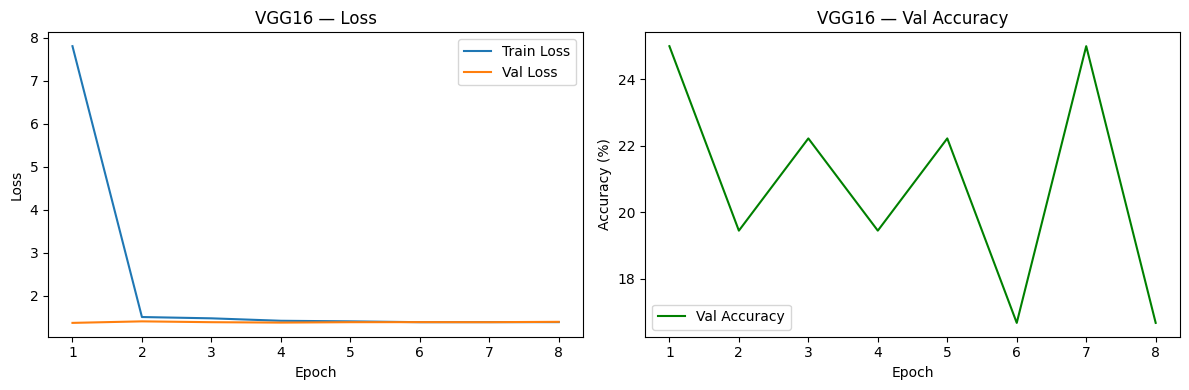


VGG16 Test Results:

Accuracy : 36.84%
Precision: 35.78%  (macro)
Recall   : 33.94%  (macro)
F1-Score : 32.92%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.33      0.10      0.15        10
       Other       0.09      0.17      0.12         6
         Sad       0.55      0.55      0.55        11
       happy       0.46      0.55      0.50        11

    accuracy                           0.37        38
   macro avg       0.36      0.34      0.33        38
weighted avg       0.39      0.37      0.36        38



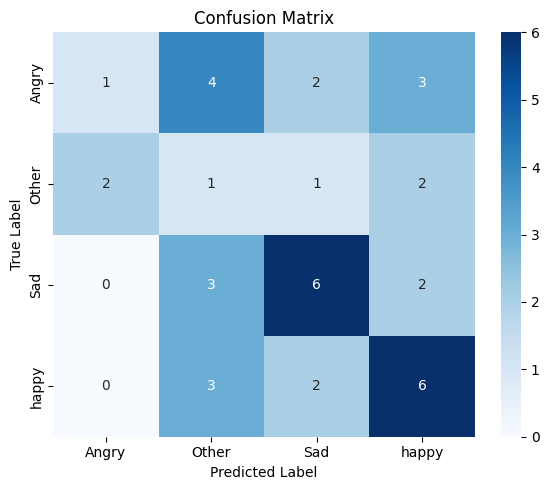

In [26]:
set_seed(42)

print("Training VGG16...")
vgg_model, vgg_history = train_model(
    VGG16(num_classes=NUM_CLASSES),
    train_loader, val_loader,
    epochs=epochs, lr=lr, patience=patience
)
plot_history(vgg_history, 'VGG16')

print("\nVGG16 Test Results:")
results_summary['VGG16'] = evaluate_model(vgg_model, test_loader, CLASS_NAMES)

Training ResNet18...
Epoch 01/30 | Train Loss: 1.5879 | Val Loss: 4.1429 | Val Acc: 27.8%
Epoch 02/30 | Train Loss: 1.4204 | Val Loss: 1.3638 | Val Acc: 30.6%
Epoch 03/30 | Train Loss: 1.3934 | Val Loss: 1.3779 | Val Acc: 27.8%
Epoch 04/30 | Train Loss: 1.4034 | Val Loss: 1.3384 | Val Acc: 30.6%
Epoch 05/30 | Train Loss: 1.4061 | Val Loss: 1.4290 | Val Acc: 36.1%
Epoch 06/30 | Train Loss: 1.3825 | Val Loss: 1.5054 | Val Acc: 27.8%
Epoch 07/30 | Train Loss: 1.4206 | Val Loss: 1.3825 | Val Acc: 33.3%
Epoch 08/30 | Train Loss: 1.3567 | Val Loss: 1.4267 | Val Acc: 27.8%
Epoch 09/30 | Train Loss: 1.3482 | Val Loss: 1.4471 | Val Acc: 33.3%
Epoch 10/30 | Train Loss: 1.3378 | Val Loss: 1.7594 | Val Acc: 13.9%
Epoch 11/30 | Train Loss: 1.3276 | Val Loss: 1.5117 | Val Acc: 33.3%
Early stopping at epoch 11


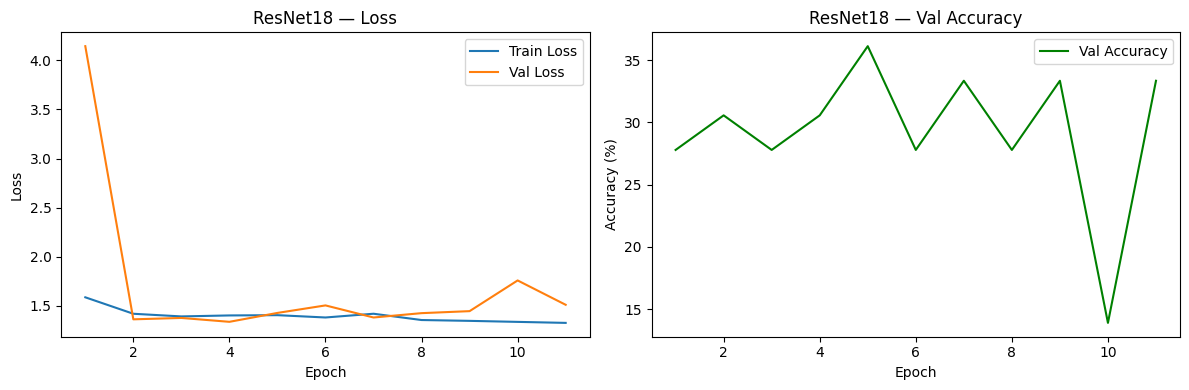


ResNet18 Test Results:

Accuracy : 36.84%
Precision: 42.22%  (macro)
Recall   : 32.95%  (macro)
F1-Score : 28.86%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.38      0.50      0.43        10
       Other       0.00      0.00      0.00         6
         Sad       0.30      0.64      0.41        11
       happy       1.00      0.18      0.31        11

    accuracy                           0.37        38
   macro avg       0.42      0.33      0.29        38
weighted avg       0.48      0.37      0.32        38



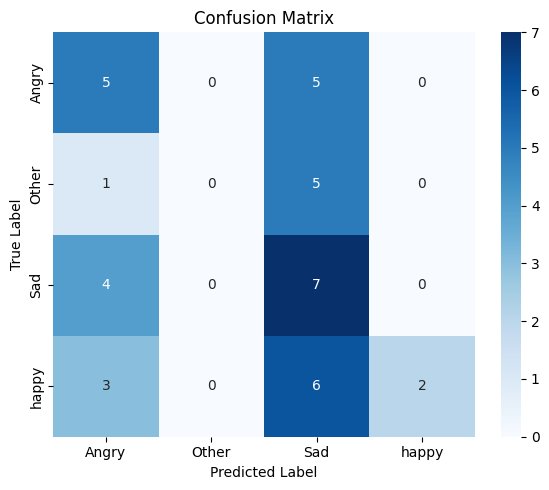

In [27]:
set_seed(42)

print("Training ResNet18...")
resnet_model, resnet_history = train_model(
    ResNet18(num_classes=NUM_CLASSES),
    train_loader, val_loader,
    epochs=epochs, lr=lr, patience=patience
)
plot_history(resnet_history, 'ResNet18')
print("\nResNet18 Test Results:")
results_summary['ResNet18'] = evaluate_model(resnet_model, test_loader, CLASS_NAMES)

Training MobileNetV1...
Epoch 01/30 | Train Loss: 1.4637 | Val Loss: 2.8162 | Val Acc: 16.7%
Epoch 02/30 | Train Loss: 1.4423 | Val Loss: 1.5969 | Val Acc: 25.0%
Epoch 03/30 | Train Loss: 1.4063 | Val Loss: 1.6252 | Val Acc: 22.2%
Epoch 04/30 | Train Loss: 1.3813 | Val Loss: 1.3308 | Val Acc: 27.8%
Epoch 05/30 | Train Loss: 1.3819 | Val Loss: 1.4862 | Val Acc: 25.0%
Epoch 06/30 | Train Loss: 1.3455 | Val Loss: 1.6391 | Val Acc: 25.0%
Epoch 07/30 | Train Loss: 1.3458 | Val Loss: 1.4789 | Val Acc: 25.0%
Epoch 08/30 | Train Loss: 1.3516 | Val Loss: 1.4474 | Val Acc: 30.6%
Epoch 09/30 | Train Loss: 1.2811 | Val Loss: 1.5105 | Val Acc: 27.8%
Epoch 10/30 | Train Loss: 1.2669 | Val Loss: 1.4768 | Val Acc: 30.6%
Epoch 11/30 | Train Loss: 1.2781 | Val Loss: 1.7124 | Val Acc: 19.4%
Early stopping at epoch 11


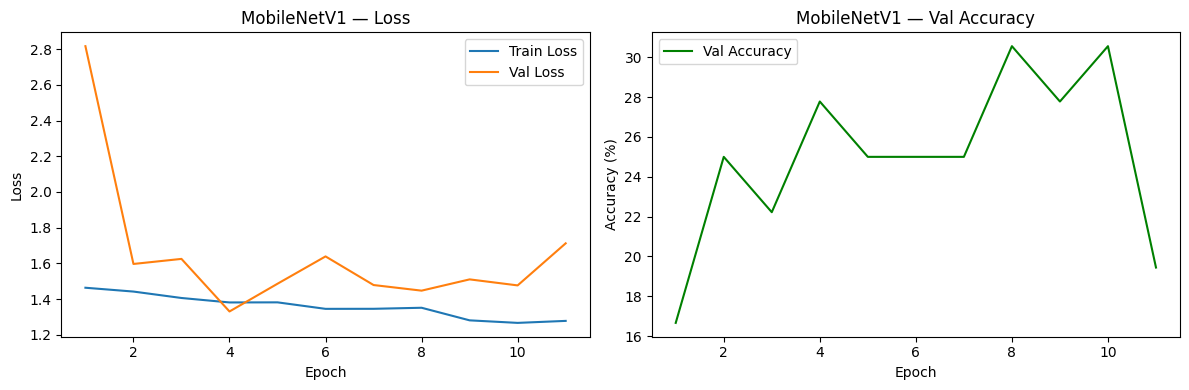


MobileNetV1 Test Results:

Accuracy : 31.58%
Precision: 30.48%  (macro)
Recall   : 30.08%  (macro)
F1-Score : 30.05%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.40      0.40      0.40        10
       Other       0.20      0.17      0.18         6
         Sad       0.33      0.27      0.30        11
       happy       0.29      0.36      0.32        11

    accuracy                           0.32        38
   macro avg       0.30      0.30      0.30        38
weighted avg       0.32      0.32      0.31        38



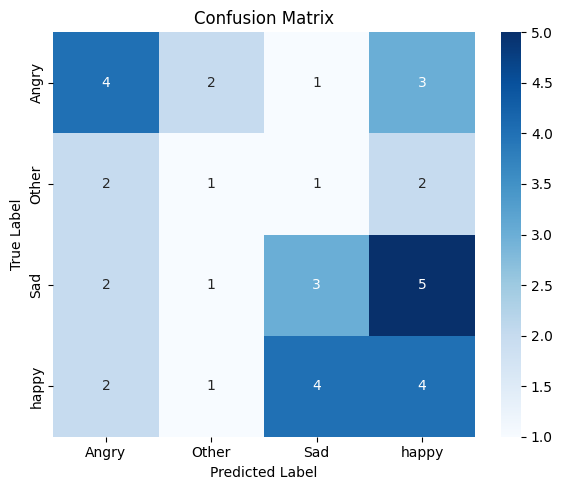

In [28]:
set_seed(42)

print("Training MobileNetV1...")
mobilenet_model, mobilenet_history = train_model(
    MobileNetV1(num_classes=NUM_CLASSES),
    train_loader, val_loader,
    epochs=30, lr=1e-3, patience=7
)
plot_history(mobilenet_history, 'MobileNetV1')
print("\nMobileNetV1 Test Results:")
results_summary['MobileNetV1'] = evaluate_model(mobilenet_model, test_loader, CLASS_NAMES)

Starting training for Inception V3...
Epoch 01/30 | Train Loss: 1.5006 | Val Loss: 1.3823 | Val Acc: 22.2%
Epoch 02/30 | Train Loss: 1.4538 | Val Loss: 1.5109 | Val Acc: 38.9%
Epoch 03/30 | Train Loss: 1.4342 | Val Loss: 1.5812 | Val Acc: 30.6%
Epoch 04/30 | Train Loss: 1.4182 | Val Loss: 1.3522 | Val Acc: 27.8%
Epoch 05/30 | Train Loss: 1.4522 | Val Loss: 1.5174 | Val Acc: 25.0%
Epoch 06/30 | Train Loss: 1.4114 | Val Loss: 1.8031 | Val Acc: 22.2%
Epoch 07/30 | Train Loss: 1.3998 | Val Loss: 1.4893 | Val Acc: 27.8%
Epoch 08/30 | Train Loss: 1.4120 | Val Loss: 1.3610 | Val Acc: 41.7%
Epoch 09/30 | Train Loss: 1.3753 | Val Loss: 1.4179 | Val Acc: 22.2%
Epoch 10/30 | Train Loss: 1.3516 | Val Loss: 1.4188 | Val Acc: 25.0%
Epoch 11/30 | Train Loss: 1.3555 | Val Loss: 1.4457 | Val Acc: 30.6%
Early stopping at epoch 11


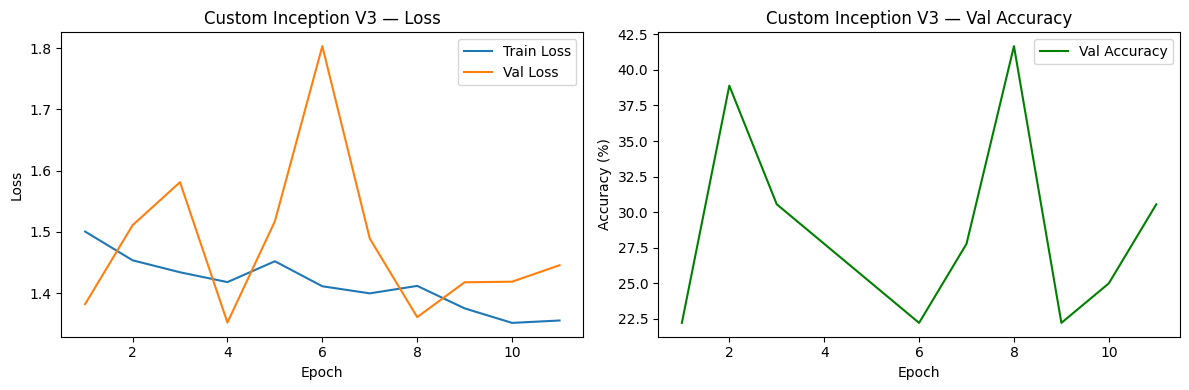


InceptionV3 Test Results:

Accuracy : 23.68%
Precision: 10.42%  (macro)
Recall   : 20.68%  (macro)
F1-Score : 12.43%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.17      0.10      0.12        10
       Other       0.00      0.00      0.00         6
         Sad       0.00      0.00      0.00        11
       happy       0.25      0.73      0.37        11

    accuracy                           0.24        38
   macro avg       0.10      0.21      0.12        38
weighted avg       0.12      0.24      0.14        38



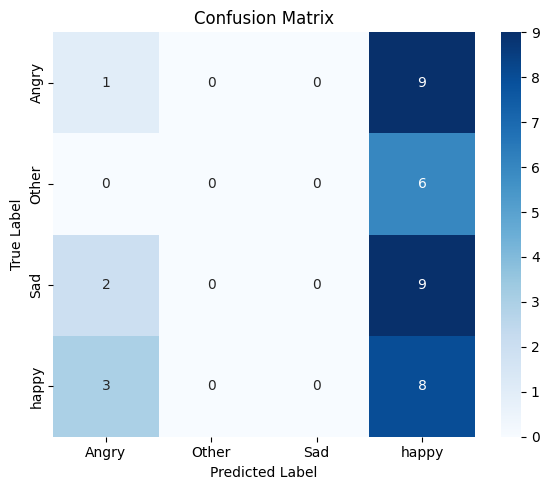

In [29]:
set_seed(42)

model_scratch = InceptionV3_FromScratch(num_classes=NUM_CLASSES, aux_logits=False)
print("Starting training for Inception V3...")
trained_inception, history_inception = train_model(
    model=model_scratch,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    lr=lr,
    patience=patience
)
plot_history(history_inception, "Custom Inception V3")

print("\nInceptionV3 Test Results:")
metrics_inception = evaluate_model(trained_inception, test_loader, CLASS_NAMES)
results_summary['Inception V3'] = metrics_inception



Starting training for DenseNet121...
Epoch 01/30 | Train Loss: 1.4732 | Val Loss: 1.6815 | Val Acc: 27.8%
Epoch 02/30 | Train Loss: 1.4017 | Val Loss: 1.3928 | Val Acc: 19.4%
Epoch 03/30 | Train Loss: 1.3703 | Val Loss: 1.3742 | Val Acc: 27.8%
Epoch 04/30 | Train Loss: 1.4135 | Val Loss: 1.2874 | Val Acc: 41.7%
Epoch 05/30 | Train Loss: 1.3709 | Val Loss: 1.3977 | Val Acc: 25.0%
Epoch 06/30 | Train Loss: 1.3696 | Val Loss: 2.9357 | Val Acc: 25.0%
Epoch 07/30 | Train Loss: 1.3686 | Val Loss: 4.4585 | Val Acc: 25.0%
Epoch 08/30 | Train Loss: 1.3528 | Val Loss: 1.4259 | Val Acc: 36.1%
Epoch 09/30 | Train Loss: 1.3294 | Val Loss: 1.4217 | Val Acc: 36.1%
Epoch 10/30 | Train Loss: 1.3215 | Val Loss: 1.4765 | Val Acc: 38.9%
Epoch 11/30 | Train Loss: 1.3068 | Val Loss: 1.3613 | Val Acc: 33.3%
Early stopping at epoch 11


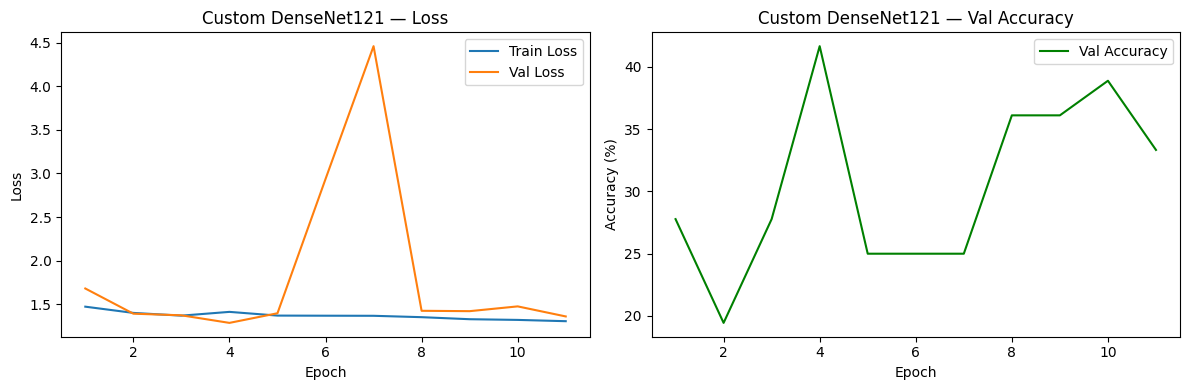


Evaluating DenseNet121 on Test Data...

Accuracy : 28.95%
Precision: 25.69%  (macro)
Recall   : 25.45%  (macro)
F1-Score : 24.31%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.33      0.20      0.25        10
       Other       0.00      0.00      0.00         6
         Sad       0.44      0.36      0.40        11
       happy       0.25      0.45      0.32        11

    accuracy                           0.29        38
   macro avg       0.26      0.25      0.24        38
weighted avg       0.29      0.29      0.27        38



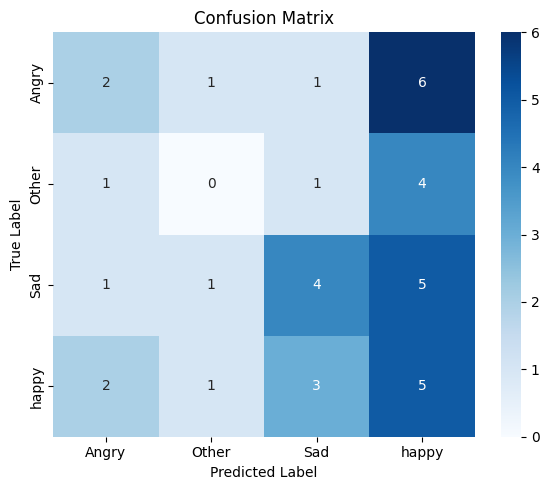

In [30]:
set_seed(42)

model_densenet = DenseNet121Scratch(num_classes=NUM_CLASSES)

print("Starting training for DenseNet121...")

trained_densenet, history_densenet = train_model(
    model=model_densenet,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    lr=lr,
    patience=patience       # Early stopping patience
)
plot_history(history_densenet, "Custom DenseNet121")
print("\nEvaluating DenseNet121 on Test Data...")
metrics_densenet = evaluate_model(trained_densenet, test_loader, CLASS_NAMES)
results_summary['DenseNet121'] = metrics_densenet


In [31]:
import pandas as pd

print("========== FINAL RESULTS SUMMARY ==========\n")

#Convert the dictionary into a pandas DataFrame for a clean table
results_df = pd.DataFrame(results_summary).T


print("Performance of all models trained from scratch:")
print("-" * 60)
print(results_df*100)
print("-" * 60)

best_model_name_f1 = results_df['f1'].idxmax()
best_model_stats_f1 = results_summary[best_model_name_f1]
print(f"\nThe best model based on F1-Score is: {best_model_name_f1.upper()}")
print("-" * 60)
best_model_name_acc = results_df['accuracy'].idxmax()
best_model_stats_acc = results_summary[best_model_name_acc]
print(f"The best model based on Accuracy is: {best_model_name_acc.upper()}")
print("-" * 60)
best_model_name_recall = results_df['recall'].idxmax()
best_model_stats_recall= results_summary[best_model_name_recall]
print(f"The best model based on Recall is: {best_model_name_recall.upper()}")
print("-" * 60)
best_model_name_prec = results_df['precision'].idxmax()
best_model_stats_prec = results_summary[best_model_name_prec]
print(f"The best model based on Precision is: {best_model_name_prec.upper()}")
print("-" * 60)


========== FINAL RESULTS SUMMARY ==========

Performance of all models trained from scratch:
------------------------------------------------------------
               accuracy  precision     recall         f1
VGG16         36.842105  35.780886  33.939394  32.923694
ResNet18      36.842105  42.224080  32.954545  28.855991
MobileNetV1   31.578947  30.476190  30.075758  30.045455
Inception V3  23.684211  10.416667  20.681818  12.427326
DenseNet121   28.947368  25.694444  25.454545  24.314516
------------------------------------------------------------

The best model based on F1-Score is: VGG16
------------------------------------------------------------
The best model based on Accuracy is: VGG16
------------------------------------------------------------
The best model based on Recall is: VGG16
------------------------------------------------------------
The best model based on Precision is: RESNET18
------------------------------------------------------------


## Transfer learning experiments
This section builds transfer learning workflows for pretrained ResNet18, DenseNet121, MobileNetV2, VGG16, and InceptionV3.
The goal is to adapt ImageNet-pretrained backbones to the pet facial expression task and compare them against models trained from scratch.

In [32]:
import torchvision.models as models
def train_transfer_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=1e-4,
    patience=5
):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=2,
        factor=0.5
    )

    best_val_loss = float('inf')
    best_weights = None
    no_improve = 0

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(1, epochs + 1):

        # ================= TRAIN =================
        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # ================= VALIDATION =================
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = outputs.argmax(1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc*100:.2f}%")

        # ================= EARLY STOPPING =================
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_weights = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            no_improve = 0

        else:

            no_improve += 1

            if no_improve >= patience:
                print("Early stopping triggered")
                break

    model.load_state_dict(best_weights)

    return model, history


=== Transfer Learning: ResNet18 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


Epoch 01/20 | Train Loss: 1.2338 | Val Loss: 1.3842 | Val Acc: 50.00%
Epoch 02/20 | Train Loss: 0.7844 | Val Loss: 1.3155 | Val Acc: 55.56%
Epoch 03/20 | Train Loss: 0.5336 | Val Loss: 1.3295 | Val Acc: 50.00%
Epoch 04/20 | Train Loss: 0.3449 | Val Loss: 1.5625 | Val Acc: 47.22%
Epoch 05/20 | Train Loss: 0.2202 | Val Loss: 1.5506 | Val Acc: 50.00%
Epoch 06/20 | Train Loss: 0.1396 | Val Loss: 1.6462 | Val Acc: 44.44%
Epoch 07/20 | Train Loss: 0.1353 | Val Loss: 1.6894 | Val Acc: 44.44%
Early stopping triggered


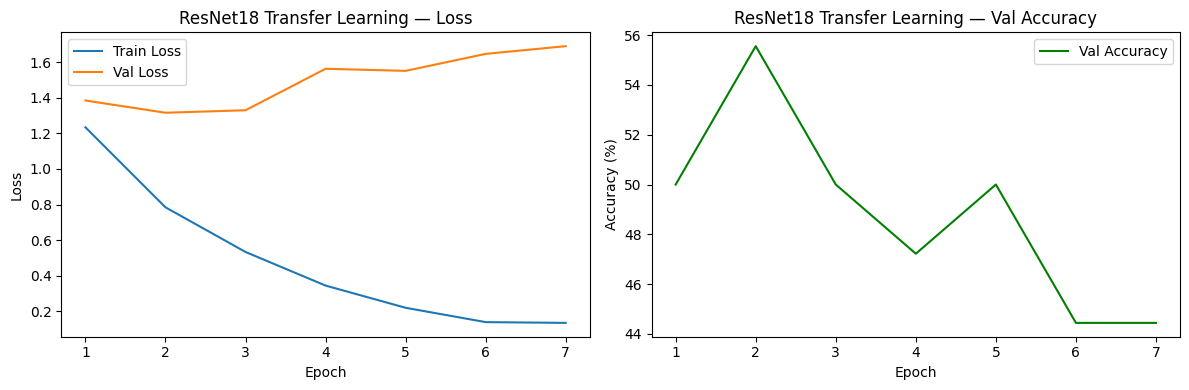


Accuracy : 52.63%
Precision: 45.91%  (macro)
Recall   : 47.27%  (macro)
F1-Score : 42.96%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.42      0.80      0.55        10
       Other       0.00      0.00      0.00         6
         Sad       0.62      0.73      0.67        11
       happy       0.80      0.36      0.50        11

    accuracy                           0.53        38
   macro avg       0.46      0.47      0.43        38
weighted avg       0.52      0.53      0.48        38



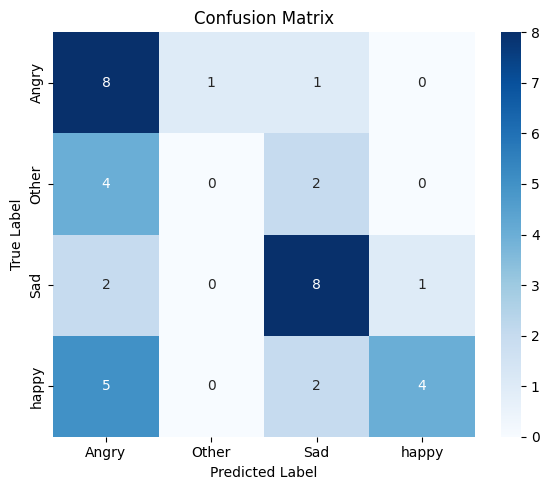

In [33]:
print("\n=== Transfer Learning: ResNet18 ===")

resnet_tl = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

# Freeze all layers first
for param in resnet_tl.parameters():
    param.requires_grad = False

# Unfreeze LAST residual block
for param in resnet_tl.layer4.parameters():
    param.requires_grad = True

# Replace classifier
resnet_tl.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(resnet_tl.fc.in_features, NUM_CLASSES)
)

trained_resnet_tl, history_resnet_tl = train_transfer_model(
    resnet_tl,
    train_loader,
    val_loader,
    epochs=20,
    lr=1e-4,
    patience=5
)

plot_history(history_resnet_tl, "ResNet18 Transfer Learning")

results_summary["ResNet18_TL"] = evaluate_model(
    trained_resnet_tl,
    test_loader,
    CLASS_NAMES
)


=== Transfer Learning: DenseNet121 ===
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 140MB/s]


Epoch 01/20 | Train Loss: 1.2763 | Val Loss: 1.3162 | Val Acc: 41.67%
Epoch 02/20 | Train Loss: 1.0312 | Val Loss: 1.3147 | Val Acc: 44.44%
Epoch 03/20 | Train Loss: 0.8726 | Val Loss: 1.2946 | Val Acc: 47.22%
Epoch 04/20 | Train Loss: 0.7452 | Val Loss: 1.3249 | Val Acc: 44.44%
Epoch 05/20 | Train Loss: 0.5982 | Val Loss: 1.3904 | Val Acc: 44.44%
Epoch 06/20 | Train Loss: 0.4363 | Val Loss: 1.4246 | Val Acc: 44.44%
Epoch 07/20 | Train Loss: 0.3436 | Val Loss: 1.4702 | Val Acc: 41.67%
Epoch 08/20 | Train Loss: 0.2948 | Val Loss: 1.6224 | Val Acc: 41.67%
Early stopping triggered


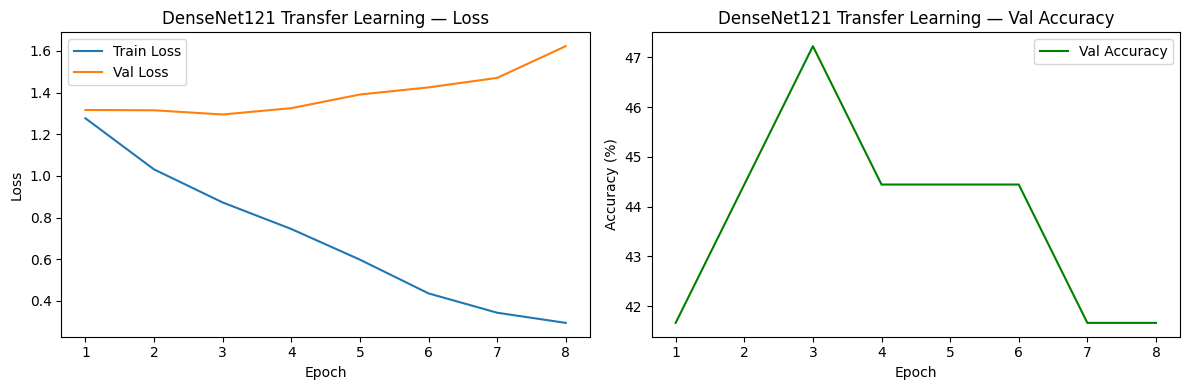


Accuracy : 52.63%
Precision: 43.30%  (macro)
Recall   : 47.27%  (macro)
F1-Score : 43.88%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.47      0.80      0.59        10
       Other       0.00      0.00      0.00         6
         Sad       0.64      0.64      0.64        11
       happy       0.62      0.45      0.53        11

    accuracy                           0.53        38
   macro avg       0.43      0.47      0.44        38
weighted avg       0.49      0.53      0.49        38



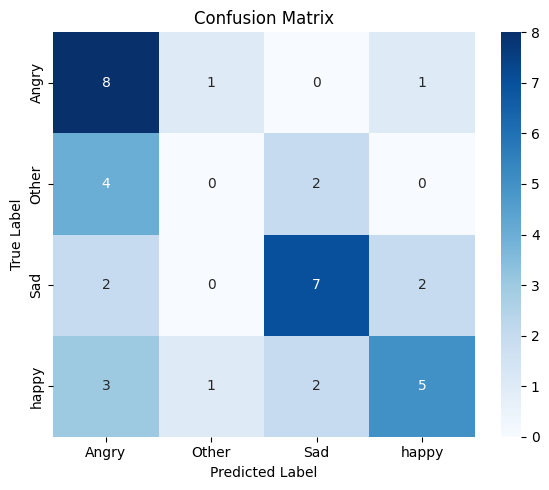

In [34]:
print("\n=== Transfer Learning: DenseNet121 ===")

densenet_tl = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# Freeze all layers
for param in densenet_tl.parameters():
    param.requires_grad = False

# Unfreeze final dense block
for param in densenet_tl.features.denseblock4.parameters():
    param.requires_grad = True

# Replace classifier
densenet_tl.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(
        densenet_tl.classifier.in_features,
        NUM_CLASSES
    )
)

trained_densenet_tl, history_densenet_tl = train_transfer_model(
    densenet_tl,
    train_loader,
    val_loader,
    epochs=20,
    lr=1e-4,
    patience=5
)

plot_history(history_densenet_tl, "DenseNet121 Transfer Learning")

results_summary["DenseNet121_TL"] = evaluate_model(
    trained_densenet_tl,
    test_loader,
    CLASS_NAMES
)


=== Transfer Learning: MobileNetV2 ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 175MB/s]


Epoch 01/15 | Train Loss: 1.3196 | Val Loss: 1.2402 | Val Acc: 50.00%
Epoch 02/15 | Train Loss: 1.1411 | Val Loss: 1.2797 | Val Acc: 41.67%
Epoch 03/15 | Train Loss: 1.0699 | Val Loss: 1.3318 | Val Acc: 38.89%
Epoch 04/15 | Train Loss: 1.0248 | Val Loss: 1.3066 | Val Acc: 44.44%
Epoch 05/15 | Train Loss: 0.9656 | Val Loss: 1.2414 | Val Acc: 41.67%
Epoch 06/15 | Train Loss: 0.9540 | Val Loss: 1.2908 | Val Acc: 47.22%
Early stopping triggered


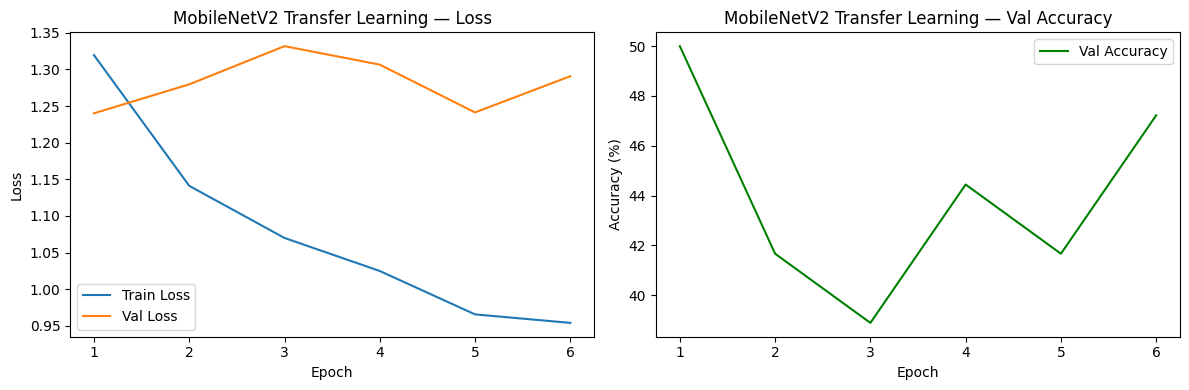


Accuracy : 47.37%
Precision: 38.93%  (macro)
Recall   : 42.95%  (macro)
F1-Score : 38.15%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.47      0.90      0.62        10
       Other       0.00      0.00      0.00         6
         Sad       0.67      0.36      0.47        11
       happy       0.42      0.45      0.43        11

    accuracy                           0.47        38
   macro avg       0.39      0.43      0.38        38
weighted avg       0.44      0.47      0.43        38



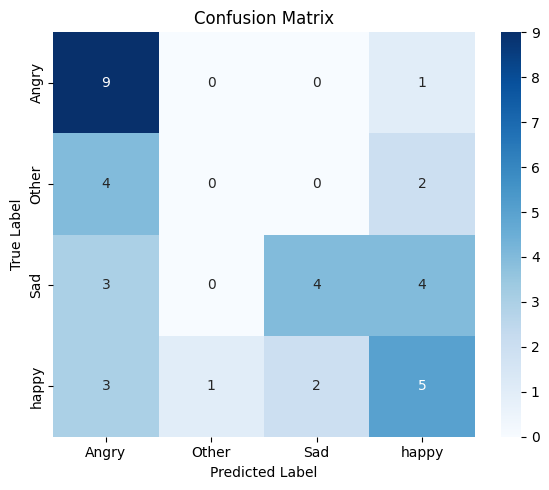

In [35]:
print("\n=== Transfer Learning: MobileNetV2 ===")

mobilenet_tl = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# freeze backbone
for param in mobilenet_tl.parameters():
    param.requires_grad = False

# replace classifier
mobilenet_tl.classifier[1] = nn.Linear(
    mobilenet_tl.classifier[1].in_features,
    NUM_CLASSES
)

trained_mobilenet_tl, history_mobilenet_tl = train_transfer_model(
    mobilenet_tl,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3
)

plot_history(history_mobilenet_tl, "MobileNetV2 Transfer Learning")

results_summary["MobileNetV2_TL"] = evaluate_model(
    trained_mobilenet_tl, test_loader, CLASS_NAMES
)


=== Transfer Learning: VGG16 ===
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 94.4MB/s]


Epoch 01/15 | Train Loss: 1.1890 | Val Loss: 1.3731 | Val Acc: 50.00%
Epoch 02/15 | Train Loss: 0.7878 | Val Loss: 1.3716 | Val Acc: 47.22%
Epoch 03/15 | Train Loss: 0.5662 | Val Loss: 1.4603 | Val Acc: 47.22%
Epoch 04/15 | Train Loss: 0.4403 | Val Loss: 1.4501 | Val Acc: 44.44%
Epoch 05/15 | Train Loss: 0.3195 | Val Loss: 1.6879 | Val Acc: 41.67%
Epoch 06/15 | Train Loss: 0.2236 | Val Loss: 2.0987 | Val Acc: 50.00%
Epoch 07/15 | Train Loss: 0.1750 | Val Loss: 2.0395 | Val Acc: 50.00%
Early stopping triggered


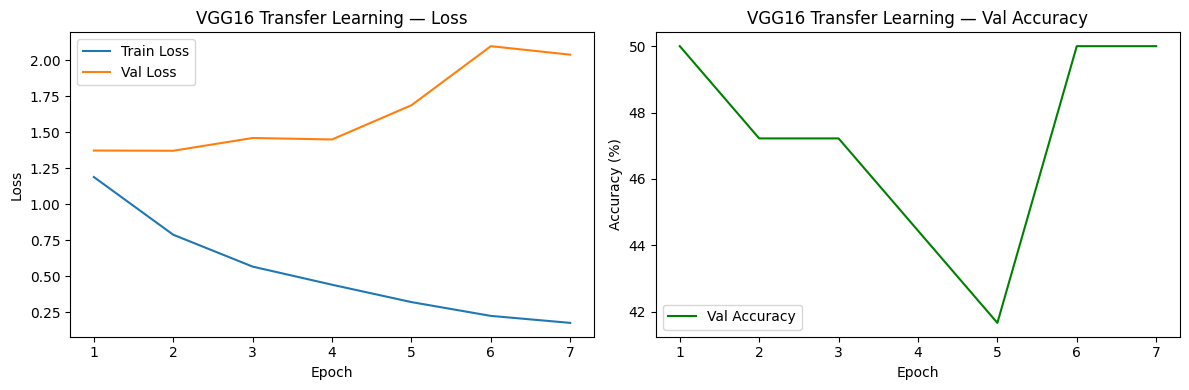


Accuracy : 50.00%
Precision: 47.62%  (macro)
Recall   : 46.89%  (macro)
F1-Score : 45.09%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.50      0.80      0.62        10
       Other       0.33      0.17      0.22         6
         Sad       0.50      0.55      0.52        11
       happy       0.57      0.36      0.44        11

    accuracy                           0.50        38
   macro avg       0.48      0.47      0.45        38
weighted avg       0.49      0.50      0.48        38



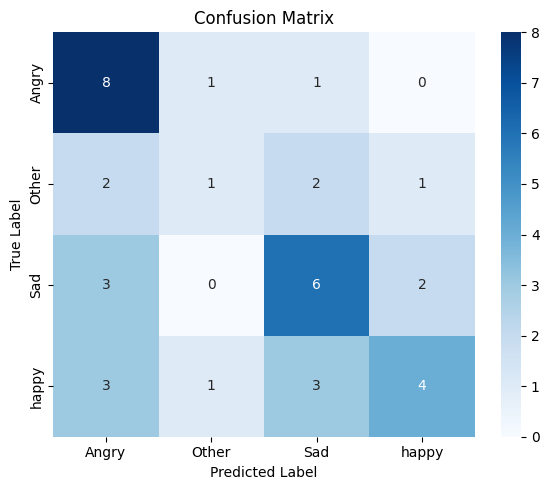

In [36]:
print("\n=== Transfer Learning: VGG16 ===")

vgg_tl = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze convolutional backbone
for param in vgg_tl.features.parameters():
    param.requires_grad = False

# Replace classifier
vgg_tl.classifier[6] = nn.Linear(
    vgg_tl.classifier[6].in_features,
    NUM_CLASSES
)

trained_vgg_tl, history_vgg_tl = train_transfer_model(
    vgg_tl,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-4,
    patience=5
)

plot_history(history_vgg_tl, "VGG16 Transfer Learning")

results_summary["VGG16_TL"] = evaluate_model(
    trained_vgg_tl,
    test_loader,
    CLASS_NAMES
)

In [37]:
INCEPTION_SIZE = 299

inception_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(INCEPTION_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

inception_eval_transform = transforms.Compose([
    transforms.Resize((INCEPTION_SIZE, INCEPTION_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

In [38]:
train_data_inception = datasets.ImageFolder(
    train_path,
    transform=inception_train_transform
)

val_data_inception = datasets.ImageFolder(
    valid_path,
    transform=inception_eval_transform
)

test_data_inception = datasets.ImageFolder(
    test_path,
    transform=inception_eval_transform
)

train_loader_inception = DataLoader(
    train_data_inception,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_inception = DataLoader(
    val_data_inception,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_inception = DataLoader(
    test_data_inception,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [39]:
def train_inception_transfer(model, train_loader, val_loader,
                             epochs=15, lr=1e-4, patience=5):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=2,
        factor=0.5
    )

    best_val_loss = float('inf')
    best_weights = None
    no_improve = 0

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(1, epochs + 1):

        # ===== TRAIN =====
        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs, aux_outputs = model(images)

            loss1 = criterion(outputs, labels)
            loss2 = criterion(aux_outputs, labels)

            loss = loss1 + 0.4 * loss2

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # ===== VALIDATION =====
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = outputs.argmax(1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc*100:.2f}%")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0

        else:
            no_improve += 1

            if no_improve >= patience:
                print("Early stopping triggered")
                break

    model.load_state_dict(best_weights)

    return model, history


=== Transfer Learning: InceptionV3 ===
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 169MB/s] 


Epoch 01/15 | Train Loss: 1.9551 | Val Loss: 1.3769 | Val Acc: 38.89%
Epoch 02/15 | Train Loss: 1.8861 | Val Loss: 1.3646 | Val Acc: 33.33%
Epoch 03/15 | Train Loss: 1.8526 | Val Loss: 1.3585 | Val Acc: 38.89%
Epoch 04/15 | Train Loss: 1.8146 | Val Loss: 1.3520 | Val Acc: 36.11%
Epoch 05/15 | Train Loss: 1.7887 | Val Loss: 1.3310 | Val Acc: 38.89%
Epoch 06/15 | Train Loss: 1.7693 | Val Loss: 1.3252 | Val Acc: 38.89%
Epoch 07/15 | Train Loss: 1.7164 | Val Loss: 1.3226 | Val Acc: 36.11%
Epoch 08/15 | Train Loss: 1.7132 | Val Loss: 1.3136 | Val Acc: 41.67%
Epoch 09/15 | Train Loss: 1.6871 | Val Loss: 1.2994 | Val Acc: 38.89%
Epoch 10/15 | Train Loss: 1.6827 | Val Loss: 1.3047 | Val Acc: 36.11%
Epoch 11/15 | Train Loss: 1.6516 | Val Loss: 1.3037 | Val Acc: 38.89%
Epoch 12/15 | Train Loss: 1.6388 | Val Loss: 1.2961 | Val Acc: 44.44%
Epoch 13/15 | Train Loss: 1.6091 | Val Loss: 1.3032 | Val Acc: 41.67%
Epoch 14/15 | Train Loss: 1.6181 | Val Loss: 1.2873 | Val Acc: 38.89%
Epoch 15/15 | Train 

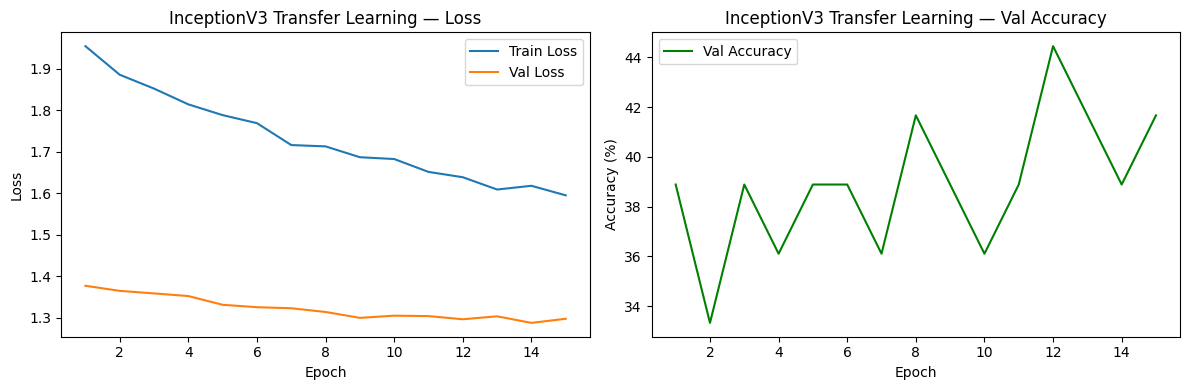


Accuracy : 39.47%
Precision: 34.70%  (macro)
Recall   : 37.80%  (macro)
F1-Score : 35.62%  (macro)

Per-class report:
              precision    recall  f1-score   support

       Angry       0.57      0.80      0.67        10
       Other       0.17      0.17      0.17         6
         Sad       0.40      0.36      0.38        11
       happy       0.25      0.18      0.21        11

    accuracy                           0.39        38
   macro avg       0.35      0.38      0.36        38
weighted avg       0.36      0.39      0.37        38



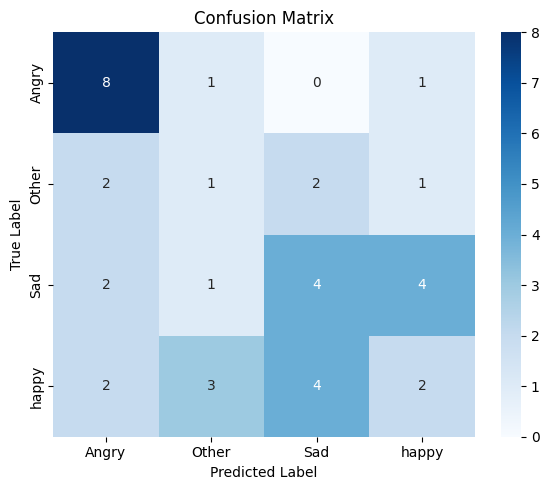

In [40]:
print("\n=== Transfer Learning: InceptionV3 ===")

inception_tl = models.inception_v3(
    weights=models.Inception_V3_Weights.IMAGENET1K_V1,
    aux_logits=True
)

# Freeze backbone
for param in inception_tl.parameters():
    param.requires_grad = False

# Main classifier
inception_tl.fc = nn.Linear(
    inception_tl.fc.in_features,
    NUM_CLASSES
)

# Auxiliary classifier
inception_tl.AuxLogits.fc = nn.Linear(
    inception_tl.AuxLogits.fc.in_features,
    NUM_CLASSES
)

trained_inception_tl, history_inception_tl = train_inception_transfer(
    inception_tl,
    train_loader_inception,
    val_loader_inception,
    epochs=15,
    lr=1e-4,
    patience=5
)

plot_history(history_inception_tl, "InceptionV3 Transfer Learning")

results_summary["InceptionV3_TL"] = evaluate_model(
    trained_inception_tl,
    test_loader_inception,
    CLASS_NAMES
)

In [41]:
results_df = pd.DataFrame(results_summary).T * 100

print("\n===== FINAL COMPARISON (Including Transfer Learning) =====")
print(results_df.sort_values("f1", ascending=False))


===== FINAL COMPARISON (Including Transfer Learning) =====
                 accuracy  precision     recall         f1
VGG16_TL        50.000000  47.619048  46.893939  45.094760
DenseNet121_TL  52.631579  43.298797  47.272727  43.881800
ResNet18_TL     52.631579  45.910931  47.272727  42.959770
MobileNetV2_TL  47.368421  38.925439  42.954545  38.151512
InceptionV3_TL  39.473684  34.702381  37.803030  35.620301
VGG16           36.842105  35.780886  33.939394  32.923694
MobileNetV1     31.578947  30.476190  30.075758  30.045455
ResNet18        36.842105  42.224080  32.954545  28.855991
DenseNet121     28.947368  25.694444  25.454545  24.314516
Inception V3    23.684211  10.416667  20.681818  12.427326


In [3]:
import pandas as pd
# Load actual results from notebook execution
results_data = {
    'VGG16_TL': {'accuracy': 0.50000000, 'precision': 0.47619048, 'recall': 0.46893939, 'f1': 0.45094760},
    'DenseNet121_TL': {'accuracy': 0.52631579, 'precision': 0.43298797, 'recall': 0.47272727, 'f1': 0.43881800},
    'ResNet18_TL': {'accuracy': 0.52631579, 'precision': 0.45910931, 'recall': 0.47272727, 'f1': 0.42959770},
    'MobileNetV2_TL': {'accuracy': 0.47368421, 'precision': 0.38925439, 'recall': 0.42954545, 'f1': 0.38151512},
    'InceptionV3_TL': {'accuracy': 0.39473684, 'precision': 0.34702381, 'recall': 0.37803030, 'f1': 0.35620301},
    'VGG16': {'accuracy': 0.36842105, 'precision': 0.35780886, 'recall': 0.33939394, 'f1': 0.32923694},
    'MobileNetV1': {'accuracy': 0.31578947, 'precision': 0.30476190, 'recall': 0.30075758, 'f1': 0.30045455},
    'ResNet18': {'accuracy': 0.36842105, 'precision': 0.42224080, 'recall': 0.32954545, 'f1': 0.28855991},
    'DenseNet121': {'accuracy': 0.28947368, 'precision': 0.25694444, 'recall': 0.25454545, 'f1': 0.24314516},
    'Inception V3': {'accuracy': 0.23684211, 'precision': 0.10416667, 'recall': 0.20681818, 'f1': 0.12427326},
}

# Create results DataFrame
results_df = pd.DataFrame(results_data).T * 100  # Convert to percentages

print("\n===== FINAL COMPARISON (Including Transfer Learning) =====")
print(results_df.round(2).sort_values("f1", ascending=False))


===== FINAL COMPARISON (Including Transfer Learning) =====
                accuracy  precision  recall     f1
VGG16_TL           50.00      47.62   46.89  45.09
DenseNet121_TL     52.63      43.30   47.27  43.88
ResNet18_TL        52.63      45.91   47.27  42.96
MobileNetV2_TL     47.37      38.93   42.95  38.15
InceptionV3_TL     39.47      34.70   37.80  35.62
VGG16              36.84      35.78   33.94  32.92
MobileNetV1        31.58      30.48   30.08  30.05
ResNet18           36.84      42.22   32.95  28.86
DenseNet121        28.95      25.69   25.45  24.31
Inception V3       23.68      10.42   20.68  12.43


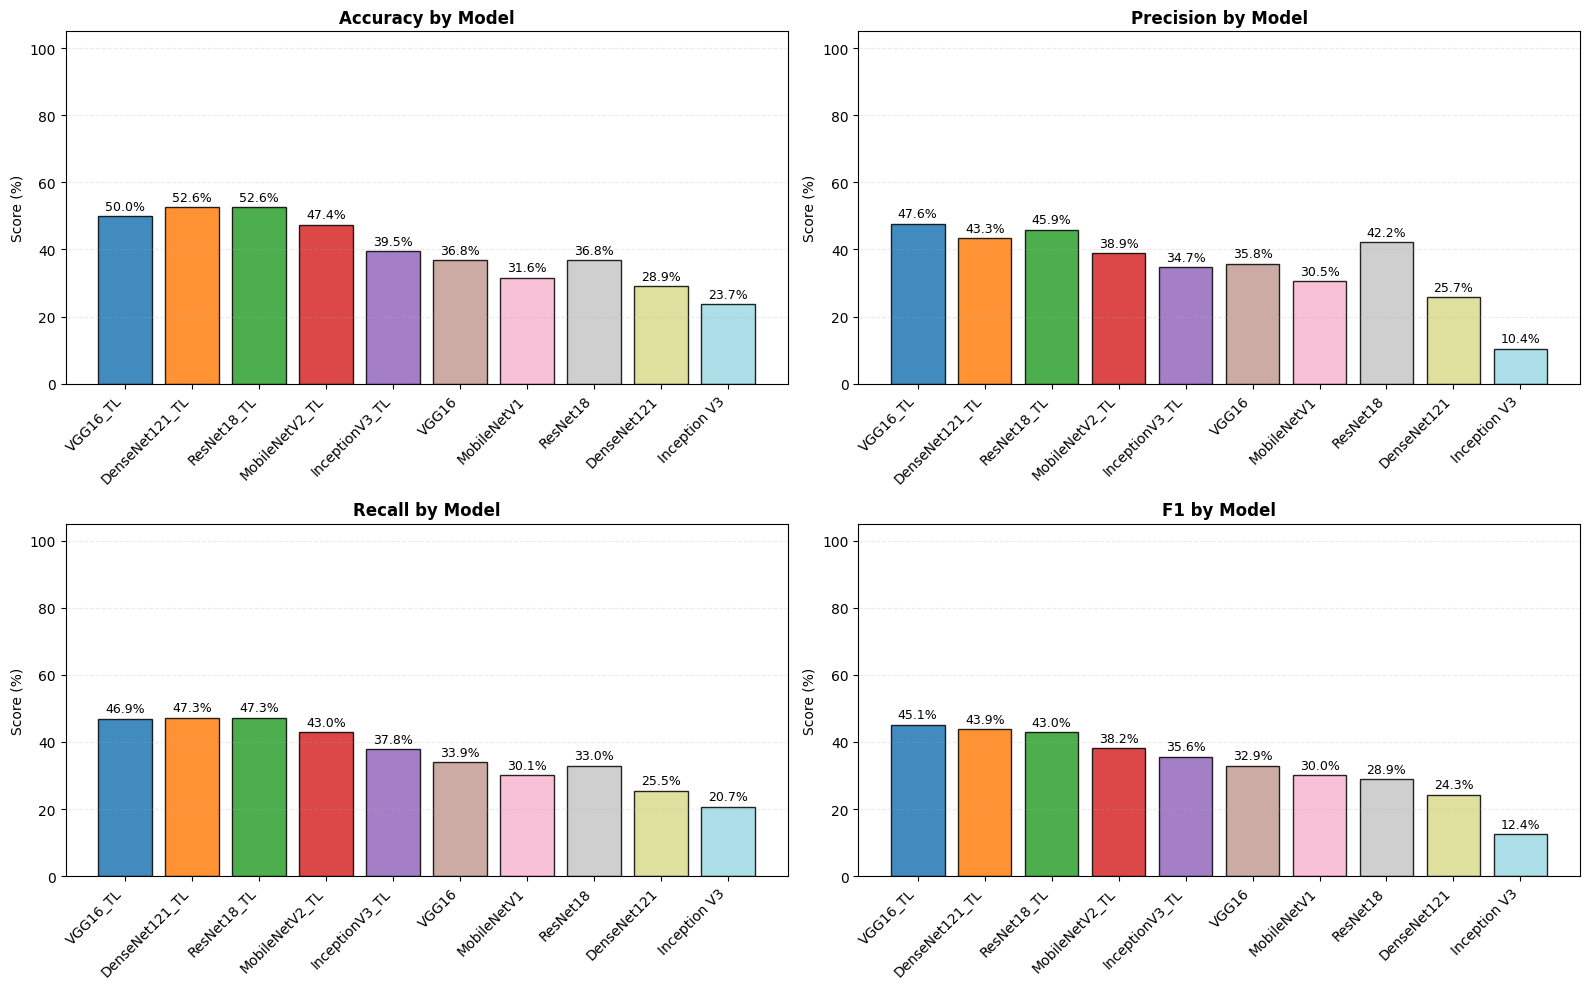

Saved: figures\accuracy_by_model.png


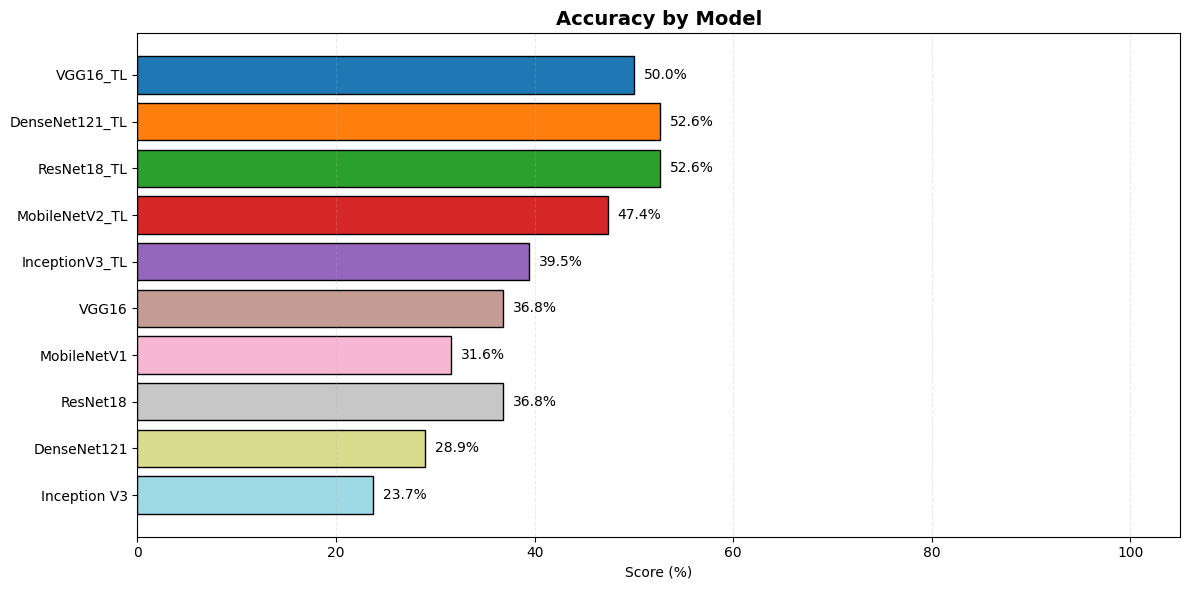

Saved: figures\precision_by_model.png


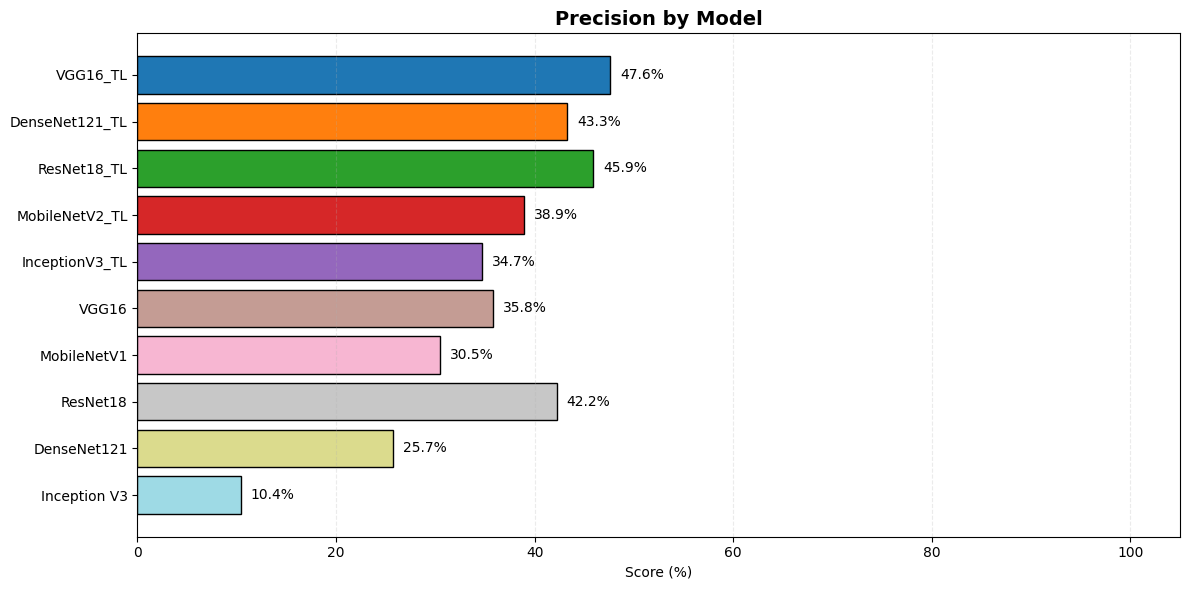

Saved: figures\recall_by_model.png


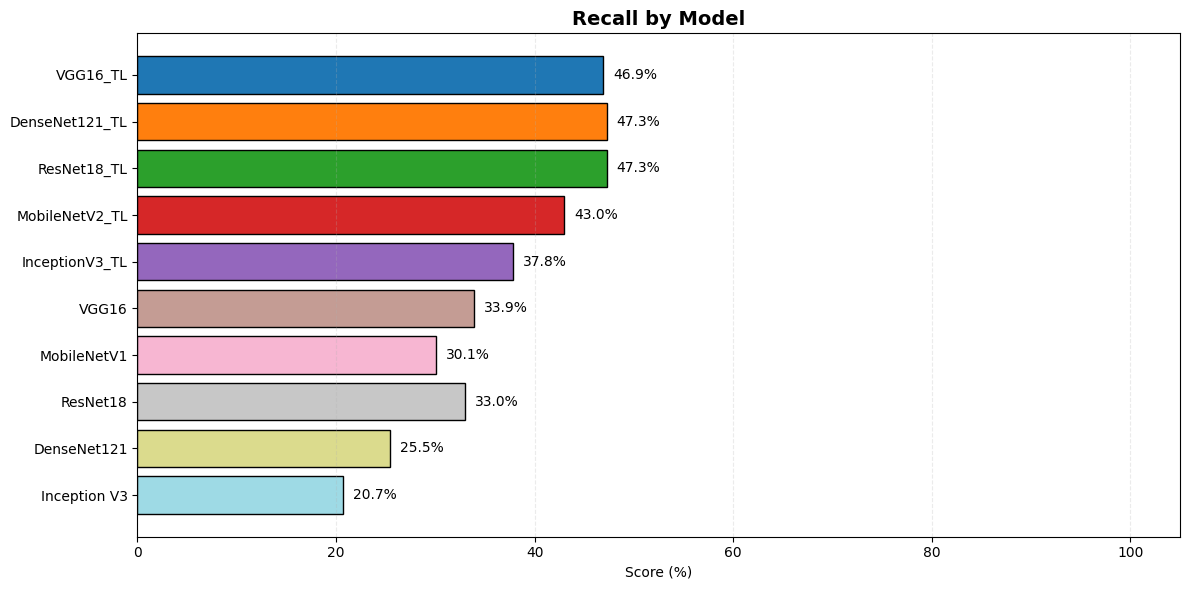

Saved: figures\f1_by_model.png


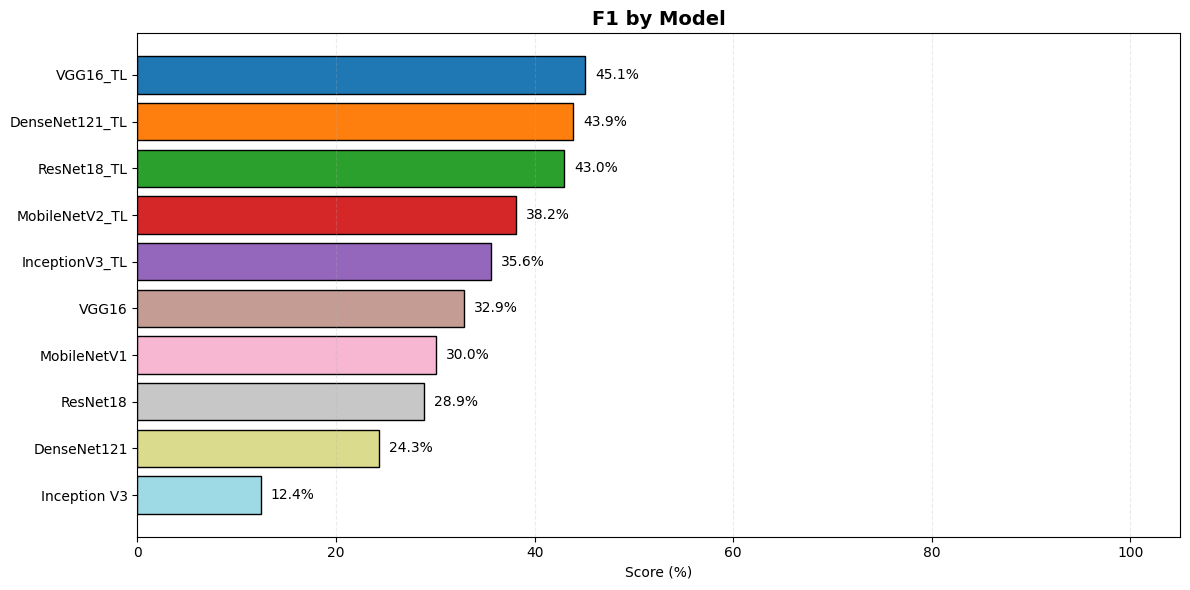


COMPREHENSIVE MODEL COMPARISON TABLE (All metrics in %)
                accuracy  precision  recall     f1
VGG16_TL           50.00      47.62   46.89  45.09
DenseNet121_TL     52.63      43.30   47.27  43.88
ResNet18_TL        52.63      45.91   47.27  42.96
MobileNetV2_TL     47.37      38.93   42.95  38.15
InceptionV3_TL     39.47      34.70   37.80  35.62
VGG16              36.84      35.78   33.94  32.92
MobileNetV1        31.58      30.48   30.08  30.05
ResNet18           36.84      42.22   32.95  28.86
DenseNet121        28.95      25.69   25.45  24.31
Inception V3       23.68      10.42   20.68  12.43

RANKINGS BY METRIC

ACCURACY Rankings:
  1. DenseNet121_TL        52.63%
  2. ResNet18_TL           52.63%
  3. VGG16_TL              50.00%
  4. MobileNetV2_TL        47.37%
  5. InceptionV3_TL        39.47%
  6. VGG16                 36.84%
  7. ResNet18              36.84%
  8. MobileNetV1           31.58%
  9. DenseNet121           28.95%
  10. Inception V3          23.68%



In [9]:
# Create comprehensive model comparison visualizations
import matplotlib.pyplot as plt
import numpy as np
import os

# Prepare data: ensure percentages
results_df_pct = results_df.copy()
if results_df_pct.max().max() <= 1.0:
    results_df_pct = results_df_pct * 100

models = results_df_pct.index.tolist()
metrics = ['accuracy', 'precision', 'recall', 'f1']

# Colors
colors = plt.cm.tab20(np.linspace(0, 1, len(models)))

# Figure A: Four separate vertical bar charts (2x2) shown inline
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = results_df_pct[metric].values
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='black')
    ax.set_title(f'{metric.capitalize()} by Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, 105)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.25, linestyle='--')

    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1.0, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Create output directory for saved figures
out_dir = 'figures'
os.makedirs(out_dir, exist_ok=True)

# Figure B: Save four separate plots (one per metric) to disk and also display them
for metric in metrics:
    fig, ax = plt.subplots(figsize=(12, 6))
    values = results_df_pct[metric].values
    bars = ax.barh(models[::-1], values[::-1], color=colors[::-1], edgecolor='black')
    ax.set_xlabel('Score (%)')
    ax.set_title(f'{metric.capitalize()} by Model', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.grid(axis='x', alpha=0.25, linestyle='--')

    # Add labels
    for i, (bar, val) in enumerate(zip(bars, values[::-1])):
        ax.text(val + 1.0, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    filename = os.path.join(out_dir, f'{metric}_by_model.png')
    fig.savefig(filename, dpi=200, bbox_inches='tight')
    print(f'Saved: {filename}')
    plt.show()

# Summary Table
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON TABLE (All metrics in %)")
print("="*80)
print(results_df_pct.round(2))
print("="*80)

# Ranking by metric
print("\n" + "="*80)
print("RANKINGS BY METRIC")
print("="*80)
for metric in metrics:
    print(f"\n{metric.upper()} Rankings:")
    ranking = results_df_pct[metric].sort_values(ascending=False)
    for i, (model, score) in enumerate(ranking.items(), 1):
        print(f"  {i}. {model:<20} {score:>6.2f}%")